# **PROYECTO FINAL- SINIESTROS VIALES 2015-2020 - SiniBogotá**

**CURSO SISTEMAS INTELIGENTES**

**Integrantes:**

*   Santiago Orjuela - santiago_orjuela@javeriana.edu.co
*   Laura Beltran Arias - beltranla@javeriana.edu.co
*   Cristhian Barrera - barrera_co@javeriana.edu.co




## **Planeación**

### Contexto:

La seguridad vial constituye uno de los principales retos de gestión pública en Bogotá, donde la alta densidad poblacional, el aumento en el uso de vehiculos y la diversidad de actores viales generan condiciones complejas de movilidad.

Para darnos una idea, entre 2021 y 2024, las muertes por siniestros viales en Bogotá presentaron un aumento sostenido, solo para 2025 se ha logrado una reducción cercana al 2% frente al 2024, esto segun estudios del Observatorio Nacional de Seguridad Vial. (11 Feb 2026, Bogota.Gov.co, Gina R Sánchez)

En adición, durante los últimos años, la ciudad ha experimentado eventos atípicos y restricciones sin precedentes, como las medidas de confinamiento por la pandemia de COVID-19, jornadas de “día sin carro”, protestas sociales y variaciones significativas en la movilidad urbana.


Estos eventos alteran drásticamente:

- El volumen de tráfico

- Los patrones de desplazamiento

- El comportamiento de los actores viales

- La capacidad de control por parte de las autoridades

Sin embargo, no es claro si estas variaciones generan reducciones sostenidas en la frecuencia de siniestros, cambios en la severidad de los mismos o efectos temporales o estructurales frente al comportamiento de los usuarios.

Por si fuera poco, aunque el Distrito impone miles de comparendos cada año como mecanismo de control y disuasión, no existe evidencia clara de su impacto real en la reducción de la siniestralidad.


### Fuentes de Datos:

**Set Principal**

Los datos de siniestros viales en Bogotá que cubren el periodo comprendido entre el 1 de enero de 2015 y el 31 de diciembre de 2020.


***Fuente:***
Secretaría Distrital de Movilidad

Este data set esta distribuido en cinco tablas:

1.   Siniestros: Detalles del Siniestro
2.   Actores Viales: Detalles de los actores viales afectados
3.   Vehiculos: Detalles de los vehiculos
4.   Hipotesis: Código causa
5.   Diccionario: Descripciones de los sets anteriores


**Datos Complementarios**

Tenemos los siguientes data sets complementarios:

1. **Calendario 2015-2020** Contiene el día de la semana, si es festivo, si hay día sin carro, si hay covid, si hay protesta o algun evento relevante.
Fuente: Creado manualmente.


2. **Clima 2015-2020** La fuente IDEAM aporta observaciones diarias de precipitación por estación en la ciudad de Bogotá, extrayendo datos en un período de tiempo del año 2015 al 2020.



**Nota:** Todos los datasets los hemos subido a Git hub.

## **Estrategia de Integración de Datos**

Para enriquecer el análisis utilizaremos una estrategia de unión por cada una de los sets de datos.  

**Estrategia de Integración** (Relaciones 1:N)

### Set Principal (Siniestros)

La base de datos de siniestros viales constituye el eje central del estudio, ya que contiene información detallada sobre la ocurrencia, severidad, localización y características de los accidentes en Bogotá.


- **Set Calendario:**
Relación: 1 a 1.
Cruce directo por FECHA para etiquetar el contexto de cada accidente.

- **Set de Vehículos:**
Relación: 1 a Varios. Un CODIGO_ACCIDENTE puede tener varios vehículos.

   Estrategia: Se debe decidir si se aplana la base (contar cuántos vehículos hubo por accidente) o si se mantiene el detalle para analizar fallas mecánicas por tipo de vehículo.

- **Set de Actor Vial:**
Relación: 1 a Varios. Un accidente involucra a varias personas con diferentes roles.

  Estrategia: Cruce por CODIGO_ACCIDENTE. Es vital para identificar, por ejemplo, cuántos heridos hubo por cada tipo de vehículo involucrado.

- **Set de Hipótesis:**
Relación: 1 a Varios. Un accidente puede tener múltiples causas (ej. Lluvia + Embriaguez).

### Set Complementario 1 (Calendario 2015-2020)

El calendario de eventos especiales y restricciones de movilidad permite contextualizar los siniestros dentro de dinámicas externas que alteran el comportamiento del tráfico y los patrones de desplazamiento urbano bajo un enfoque de caracter temporal.

- **Calendario 2015 a 2020:**
Relación: Varios a Varios. Permite identificar eventos importantes mediante el cruce de fechas para las cuales ocurrieron los siniestros (ej. Dia festivo, día sin carro, protestas, etc.).


### Set Complementario 2 (Clima 2015-2020)

La fuente IDEAM aporta observaciones diarias de precipitación por estación; para integrarlas con la unidad de análisis accidente, se construyen variables agregadas diarias a nivel ciudad.



In [2]:
# DICCIONARIO SINIESTRALIDAD

import pandas as pd

siniestros_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'HORA', 'GRAVEDAD', 'CLASE_SINIESTRO',
        'CHOQUE', 'OBJETO_FIJO', 'DIRECCION', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String', 'String', 'String',
        'String', 'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro',
        'Fecha del evento (DD/MM/AAAA)',
        'Hora del reporte del accidente',
        'Código Nivel de afectación (Muertos, Heridos, Daños)',
        'Código Tipo de accidente (Choque, Atropello, etc.)',
        'Código (Carro, Tren, Objetivo Fijo, Semoviente)',
        'Código Elemento chocado (Poste, árbol, semáforo, etc.)',
        'Ubicación de la colisión',
        'Identificador de la localidad en Bogotá',
        'Código Tipo de infraestructura (Intersección, tramo, puente, ect.)'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '01:05:00', '2', '2',
        '1', '2', 'KR 64A-CL 2C 02', '16', '2'
    ]
}

df_siniestros_dictionary = pd.DataFrame(siniestros_data)


In [3]:

# Diccionario Actor Vial
actor_vial_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'CODIGO_ACCIDENTADO', 'FECHA',
        'CONDICION', 'ESTADO', 'EDAD', 'SEXO', 'VEHICULO'
    ],
    'Tipo de Dato': [
        'String', 'String', 'Date',
        'String', 'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro (Llave de unión)',
        'ID único de la persona involucrada',
        'Fecha del evento (DD/MM/AAAA)',
        'Rol del actor (Conductor, Peatón, Pasajero, etc.)',
        'Gravedad física (Ileso, Herido, Muerto)',
        'Años de la persona involucrada',
        'Género del actor vial',
        'ID del vehículo asociado al actor'
    ],
    'Ejemplo': [
        '4401447', '2452576', '01/01/2015',
        'CONDUCTOR', 'ILESO', '44', 'FEMENINO', '4401447-1'
    ]
}

# Generar el DataFrame
df_actor_vial_dictionary = pd.DataFrame(actor_vial_data)


In [4]:
# Diccionario para la base de Vehículos
vehiculos_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'VEHICULO',
        'CLASE_VEHICULO', 'SERVICIO', 'MODALIDAD', 'ENFUGA'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String',
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'ID único del siniestro (Llave de unión)',
        'Fecha del evento (DD/MM/AAAA)',
        'ID interno del vehículo en el accidente',
        'Código Tipo de vehículo (Automóvil, Bus, Camión, etc.)',
        'Código Tipo de servicio (Particular, Público, Diplomático)',
        'Código Tipo de transporte (Pasajeros, Carga, Escolar)',
        'Indica si el conductor huyó del lugar (S/N)'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '4401438-1',
        '1', '2', '5', 'N'
    ]
}

df_vehiculos_dictionary = pd.DataFrame(vehiculos_data)


In [5]:
# Diccionario set de Hipótesis
hipotesis_data = {
    'Campo': [
        'CODIGO_ACCIDENTE', 'FECHA', 'CODIGO_CAUSA'
    ],
    'Tipo de Dato': [
        'String', 'Date', 'String'
    ],
    'Description': [
        'ID único del siniestro (Llave de unión)',
        'Fecha del evento (DD/MM/AAAA)',
        'Código de la causa probable del accidente'
    ],
    'Ejemplo': [
        '4401438', '01/01/2015', '112'
    ]
}

df_hipotesis_dictionary = pd.DataFrame(hipotesis_data)


In [6]:
# Diccionario maestro de códigos (mapeo de descripciones)
diccionario_maestro_data = {
    'Campo': [
        'HOJA', 'CAMPO', 'CODIGO', 'DESCRIPCION'
    ],
    'Tipo de Dato': [
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'Nombre de la tabla a la que pertenece el código',
        'Nombre de la columna que contiene el código',
        'Valor dentro de la base de datos',
        'Significado del código (ej. 1 = Con Muertos)'
    ],
    'Ejemplo': [
        'SINIESTROS', 'GRAVEDAD', '2', 'CON HERIDOS'
    ]
}

df_maestro_dictionary = pd.DataFrame(diccionario_maestro_data)


In [7]:
# DICCIONARIO CALENDARIO

data_dictionary = {
    'Campo': [
        'Fecha', 'Dia_Semana', 'Festivo', 'Dia_sin_carro',
        'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'Nombre_Evento'
    ],
    'Tipo de Dato': [
        'Date', 'String', 'String', 'String',
        'String', 'String', 'String', 'String'
    ],
    'Descripción': [
        'Día del año (Llave de unión)',
        'Describe el día de la semana',
        'Flag de día Feriado',
        'Flag de día sin carro',
        'Flag de protesta',
        'Flag de restricciones sanitarias',
        'Flag de realización de Eventos o fechas importantes',
        'Descripción del evento'
    ],
    'Ejemplo': [
        '01/05/2018', 'Martes', 'SI', 'NO',
        'SI', 'NO', 'SI', 'Día del Trabajo'
    ]
}

df_calernario_dictionary = pd.DataFrame(data_dictionary)


In [8]:
# Diccionario Clima

clima_data = {
    'Campo': [
        'CodigoEstacion', 'NombreEstacion', 'Variable', 'Parametro',
        'Fecha', 'Unidad', 'Valor', 'NivelAprobacion'
    ],
    'Tipo de Dato': [
        'String', 'String', 'String', 'String',
        'Date', 'String', 'Float', 'String'
    ],
    'Descripción': [
        'Código único de la estación hidrometeorológica del IDEAM',
        'Nombre de la estación que reporta la observación',
        'Variable meteorológica observada (en este archivo: precipitación)',
        'Definición del parámetro reportado por el IDEAM',
        'Fecha del registro diario',
        'Unidad de medida del valor reportado',
        'Valor observado de precipitación para la fecha y estación',
        'Nivel de validación/calidad del dato reportado por el IDEAM'
    ],
    'Ejemplo': [
        '21201300', 'AUSTRALIA [21201300]', 'PRECIPITACION',
        'Día pluviométrico (convencional)', '01/01/2015', 'mm', '0.0', 'Definitivo'
    ]
}

df_clima_dictionary = pd.DataFrame(clima_data)

## **Diccionarios de Datos**

In [9]:
print("DICCIONARIO DE DATOS: SET SINIESTROS")
display(df_siniestros_dictionary)


DICCIONARIO DE DATOS: SET SINIESTROS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro,4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,HORA,String,Hora del reporte del accidente,01:05:00
3,GRAVEDAD,String,"Código Nivel de afectación (Muertos, Heridos, ...",2
4,CLASE_SINIESTRO,String,"Código Tipo de accidente (Choque, Atropello, e...",2
5,CHOQUE,String,"Código (Carro, Tren, Objetivo Fijo, Semoviente)",1
6,OBJETO_FIJO,String,"Código Elemento chocado (Poste, árbol, semáfor...",2
7,DIRECCION,String,Ubicación de la colisión,KR 64A-CL 2C 02
8,CODIGO_LOCALIDAD,String,Identificador de la localidad en Bogotá,16
9,DISENO_LUGAR,String,"Código Tipo de infraestructura (Intersección, ...",2


In [10]:
print("DICCIONARIO DE DATOS: SET ACTOR VIAL")
display(df_actor_vial_dictionary)


DICCIONARIO DE DATOS: SET ACTOR VIAL


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401447
1,CODIGO_ACCIDENTADO,String,ID único de la persona involucrada,2452576
2,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
3,CONDICION,String,"Rol del actor (Conductor, Peatón, Pasajero, etc.)",CONDUCTOR
4,ESTADO,String,"Gravedad física (Ileso, Herido, Muerto)",ILESO
5,EDAD,String,Años de la persona involucrada,44
6,SEXO,String,Género del actor vial,FEMENINO
7,VEHICULO,String,ID del vehículo asociado al actor,4401447-1


In [11]:
print("DICCIONARIO DE DATOS: SET VEHÍCULOS")
display(df_vehiculos_dictionary)


DICCIONARIO DE DATOS: SET VEHÍCULOS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,VEHICULO,String,ID interno del vehículo en el accidente,4401438-1
3,CLASE_VEHICULO,String,"Código Tipo de vehículo (Automóvil, Bus, Camió...",1
4,SERVICIO,String,"Código Tipo de servicio (Particular, Público, ...",2
5,MODALIDAD,String,"Código Tipo de transporte (Pasajeros, Carga, E...",5
6,ENFUGA,String,Indica si el conductor huyó del lugar (S/N),N


In [12]:
print("DICCIONARIO DE DATOS: SET HIPÓTESIS")
display(df_hipotesis_dictionary)


DICCIONARIO DE DATOS: SET HIPÓTESIS


,Campo,Tipo de Dato,Description,Ejemplo
0,CODIGO_ACCIDENTE,String,ID único del siniestro (Llave de unión),4401438
1,FECHA,Date,Fecha del evento (DD/MM/AAAA),01/01/2015
2,CODIGO_CAUSA,String,Código de la causa probable del accidente,112


In [13]:
print("DICCIONARIO DE REFERENCIA: MAESTRO DE CÓDIGOS")
display(df_maestro_dictionary)

DICCIONARIO DE REFERENCIA: MAESTRO DE CÓDIGOS


,Campo,Tipo de Dato,Descripción,Ejemplo
0,HOJA,String,Nombre de la tabla a la que pertenece el código,SINIESTROS
1,CAMPO,String,Nombre de la columna que contiene el código,GRAVEDAD
2,CODIGO,String,Valor dentro de la base de datos,2
3,DESCRIPCION,String,Significado del código (ej. 1 = Con Muertos),CON HERIDOS


In [14]:
print("DICCIONARIO DE DATOS: CALENDARIO 2015-2020")
display(df_calernario_dictionary)

DICCIONARIO DE DATOS: CALENDARIO 2015-2020


,Campo,Tipo de Dato,Descripción,Ejemplo
0,Fecha,Date,Día del año (Llave de unión),01/05/2018
1,Dia_Semana,String,Describe el día de la semana,Martes
2,Festivo,String,Flag de día Feriado,SI
3,Dia_sin_carro,String,Flag de día sin carro,NO
4,Hubo_Protesta,String,Flag de protesta,SI
5,Es_COVID,String,Flag de restricciones sanitarias,NO
6,Hay_Evento,String,Flag de realización de Eventos o fechas import...,SI
7,Nombre_Evento,String,Descripción del evento,Día del Trabajo


In [15]:
# DICCIONARIO CLIMA
print("DICCIONARIO DE DATOS: CLIMA IDEAM 2015-2020")
df_clima_dictionary

DICCIONARIO DE DATOS: CLIMA IDEAM 2015-2020


,Campo,Tipo de Dato,Descripción,Ejemplo
0,CodigoEstacion,String,Código único de la estación hidrometeorológica...,21201300
1,NombreEstacion,String,Nombre de la estación que reporta la observación,AUSTRALIA [21201300]
2,Variable,String,Variable meteorológica observada (en este arch...,PRECIPITACION
3,Parametro,String,Definición del parámetro reportado por el IDEAM,Día pluviométrico (convencional)
4,Fecha,Date,Fecha del registro diario,01/01/2015
5,Unidad,String,Unidad de medida del valor reportado,mm
6,Valor,Float,Valor observado de precipitación para la fecha...,0.0
7,NivelAprobacion,String,Nivel de validación/calidad del dato reportado...,Definitivo


## **Carga de datos**

In [16]:
# SET DE SINIESTROS PRINCIPAL 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/siniestros.csv'
df_siniestros = pd.read_csv(url, sep=';')

# Renombrar CLASE para evitar ambigüedad con la tabla de vehículos
df_siniestros = df_siniestros.rename(columns={
    'CLASE': 'CLASE_SINIESTRO'
})

# convertir FECHA correctamente como dia/mes/año
df_siniestros['FECHA'] = pd.to_datetime(
    df_siniestros['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)

df_siniestros.head(12)


,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1
5,4497235,2017-10-23,08:10:00,2,1,1.0,NaN,AC 06-KR 24 02,14,2
6,4478067,2017-04-06,13:30:00,3,1,1.0,NaN,AC 06-KR 26 02,14,1
7,4475643,2017-03-13,20:30:00,3,1,1.0,NaN,AC 09-KR 108 38,1,1
8,4471672,2017-02-03,07:15:00,3,1,1.0,NaN,AC 1-KR 10A 66,3,1
9,4502355,2017-12-11,15:41:00,1,2,NaN,NaN,AC 1-KR 11A 02,3,1


In [17]:
df_siniestros.count()

CODIGO_ACCIDENTE    196152
FECHA               196152
HORA                196152
GRAVEDAD            196152
CLASE_SINIESTRO     196152
CHOQUE              167910
OBJETO_FIJO           6689
DIRECCION           196152
CODIGO_LOCALIDAD    196152
DISENO_LUGAR        196152
dtype: int64

In [18]:
# SET DE ACTOR_VIAL 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/actor_vial.csv'
df_actor_vial = pd.read_csv(url, sep=';')
df_actor_vial['FECHA'] = pd.to_datetime(
    df_actor_vial['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_actor_vial.head(2)

,CODIGO_ACCIDENTE,CODIGO_ACCIDENTADO,FECHA,CONDICION,ESTADO,EDAD,SEXO,VEHICULO
0,4401447,2452576,2015-01-01,CONDUCTOR,ILESO,44,F,4401447-1
1,4401447,2452577,2015-01-01,CONDUCTOR,ILESO,31,M,4401447-2


In [19]:
df_actor_vial.count()

CODIGO_ACCIDENTE      422416
CODIGO_ACCIDENTADO    422416
FECHA                 422416
CONDICION             422416
ESTADO                422416
EDAD                  422416
SEXO                  422416
VEHICULO              398969
dtype: int64

In [20]:
# SET DE VEHICULOS 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/vehiculos.csv'
df_vehiculos = pd.read_csv(url, sep=';')

# Renombrar CLASE para evitar ambigüedad con la tabla de siniestros
df_vehiculos = df_vehiculos.rename(columns={
    'CLASE': 'CLASE_VEHICULO'
})

df_vehiculos['FECHA'] = pd.to_datetime(
    df_vehiculos['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_vehiculos.head(2)


,CODIGO_ACCIDENTE,FECHA,VEHICULO,CLASE_VEHICULO,SERVICIO,MODALIDAD,ENFUGA
0,4401423,2015-01-01,4401423-1,1.0,2.0,5.0,N
1,4401423,2015-01-01,4401423-2,1.0,3.0,NaN,N


In [21]:
df_vehiculos.count()

CODIGO_ACCIDENTE    371605
FECHA               371605
VEHICULO            371605
CLASE_VEHICULO      368751
SERVICIO            355918
MODALIDAD           143685
ENFUGA              371605
dtype: int64

In [22]:
# SET DE HIPOTESIS 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/hipotesis.csv'
df_hipotesis = pd.read_csv(url, sep=';')
df_hipotesis['FECHA'] = pd.to_datetime(
    df_hipotesis['FECHA'],
    format='%d/%m/%Y',
    errors='coerce'
)
df_hipotesis.head(2)

,CODIGO_ACCIDENTE,FECHA,CODIGO_CAUSA
0,4401425,2015-01-01,115
1,4401437,2015-01-01,104


In [23]:
df_hipotesis.count()

CODIGO_ACCIDENTE    233819
FECHA               233819
CODIGO_CAUSA        233819
dtype: int64

In [24]:
# SET DE DICCIONARIO MAESTRO 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/maestro_diccionario.csv'
df_diccionario_maestro = pd.read_csv(url, sep=';')
df_diccionario_maestro.head(10)


,HOJA,CAMPO,CODIGO,DESCRIPCION
0,SINIESTROS,GRAVEDAD,1,Con Muertos
1,SINIESTROS,GRAVEDAD,2,Con Heridos
2,SINIESTROS,GRAVEDAD,3,Solo Daños
3,SINIESTROS,CLASE,7,Autolesion
4,SINIESTROS,CLASE,1,Choque
5,SINIESTROS,CLASE,2,Atropello
6,SINIESTROS,CLASE,4,Caida de ocupante
7,SINIESTROS,CLASE,3,Volcamiento
8,SINIESTROS,CLASE,6,Otro
9,SINIESTROS,CLASE,5,Incendio


In [25]:
# Corrección de nombres ambiguos en el diccionario maestro
df_diccionario_maestro = df_diccionario_maestro.copy()

df_diccionario_maestro['CAMPO_MODELO'] = df_diccionario_maestro['CAMPO']

df_diccionario_maestro.loc[
    (df_diccionario_maestro['HOJA'].str.upper() == 'SINIESTROS') &
    (df_diccionario_maestro['CAMPO'].str.upper() == 'CLASE'),
    'CAMPO_MODELO'
] = 'CLASE_SINIESTRO'

df_diccionario_maestro.loc[
    (df_diccionario_maestro['HOJA'].str.upper() == 'VEHICULOS') &
    (df_diccionario_maestro['CAMPO'].str.upper() == 'CLASE'),
    'CAMPO_MODELO'
] = 'CLASE_VEHICULO'

# Verificación
df_diccionario_maestro[
    df_diccionario_maestro['CAMPO_MODELO'].isin(['CLASE_SINIESTRO', 'CLASE_VEHICULO'])
][['HOJA', 'CAMPO', 'CAMPO_MODELO', 'CODIGO', 'DESCRIPCION']].sort_values(
    by=['CAMPO_MODELO', 'CODIGO']
)

,HOJA,CAMPO,CAMPO_MODELO,CODIGO,DESCRIPCION
4,SINIESTROS,CLASE,CLASE_SINIESTRO,1,Choque
5,SINIESTROS,CLASE,CLASE_SINIESTRO,2,Atropello
7,SINIESTROS,CLASE,CLASE_SINIESTRO,3,Volcamiento
6,SINIESTROS,CLASE,CLASE_SINIESTRO,4,Caida de ocupante
9,SINIESTROS,CLASE,CLASE_SINIESTRO,5,Incendio
8,SINIESTROS,CLASE,CLASE_SINIESTRO,6,Otro
3,SINIESTROS,CLASE,CLASE_SINIESTRO,7,Autolesion
58,VEHICULOS,CLASE,CLASE_VEHICULO,1,Automovil
59,VEHICULOS,CLASE,CLASE_VEHICULO,2,Bus
60,VEHICULOS,CLASE,CLASE_VEHICULO,3,Buseta


In [26]:
# SET DE DATOS CALENDARIO 2015-2020

url = 'https://raw.githubusercontent.com/barrercr/Calendario_2015_2020/refs/heads/main/Calendario_Bogota_2015_2020.csv'
df_calendario = pd.read_csv(url)

df_calendario['Fecha'] = pd.to_datetime(
    df_calendario['Fecha'],
    format='%d/%m/%Y',
    errors='coerce'
)

df_calendario.head(10)

,Fecha,Dia_Semana,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento,Nombre_Evento
0,2015-01-01,Jueves,SI,NO,NO,NO,SI,Año Nuevo
1,2015-01-02,Viernes,NO,NO,NO,NO,NO,Sin_Registro
2,2015-01-03,Sábado,NO,NO,NO,NO,NO,Sin_Registro
3,2015-01-04,Domingo,NO,NO,NO,NO,NO,Sin_Registro
4,2015-01-05,Lunes,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
5,2015-01-06,Martes,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
6,2015-01-07,Miercoles,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
7,2015-01-08,Jueves,NO,NO,NO,NO,SI,Fiesta de Reyes - Carnaval de Bogota
8,2015-01-09,Viernes,NO,NO,NO,NO,NO,Sin_Registro
9,2015-01-10,Sábado,NO,NO,NO,NO,NO,Sin_Registro


In [27]:
df_calendario.count()

Fecha            2192
Dia_Semana       2192
Festivo          2192
Dia_sin_carro    2192
Hubo_Protesta    2192
Es_COVID         2192
Hay_Evento       2192
Nombre_Evento    2186
dtype: int64

In [28]:
# SET DE DATOS CLIMA IDEAM 2015-2020 (precipitación)
url_clima = 'https://raw.githubusercontent.com/Vankold1/SiniBogota/refs/heads/main/descargaDhime.csv'

df_clima_raw = pd.read_csv(url_clima)
df_clima_raw.head(10)

,CodigoEstacion,NombreEstacion,Variable,Parametro,Fecha,Unidad,Valor,NivelAprobacion
0,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-01 00:00,mm,0.0,Definitivo
1,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-02 00:00,mm,0.0,Definitivo
2,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-03 00:00,mm,0.0,Definitivo
3,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-04 00:00,mm,0.0,Definitivo
4,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-05 00:00,mm,0.0,Definitivo
5,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-06 00:00,mm,0.0,Definitivo
6,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-07 00:00,mm,0.0,Definitivo
7,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-08 00:00,mm,0.0,Definitivo
8,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-09 00:00,mm,0.0,Definitivo
9,21201300,AUSTRALIA [21201300],PRECIPITACION,Día pluviométrico (convencional),2015-01-10 00:00,mm,0.0,Definitivo


In [29]:
# LIMPIEZA Y AGREGACIÓN DEL SET DE CLIMA

df_clima_raw.columns = [c.strip() for c in df_clima_raw.columns]

df_clima = df_clima_raw.copy()
df_clima['Fecha'] = pd.to_datetime(df_clima['Fecha'], errors='coerce')
df_clima['Variable'] = df_clima['Variable'].astype(str).str.strip().str.upper()
df_clima['Parametro'] = df_clima['Parametro'].astype(str).str.strip()
df_clima['NivelAprobacion'] = df_clima['NivelAprobacion'].astype(str).str.strip()
df_clima['Valor'] = pd.to_numeric(df_clima['Valor'], errors='coerce')

# Mantener únicamente precipitación válida
df_clima = df_clima[
    (df_clima['Variable'] == 'PRECIPITACION') &
    (df_clima['Fecha'].between('2015-01-01', '2020-12-31'))
].copy()

# Resumen por fecha a nivel Bogotá.
df_clima_bogota = (
    df_clima
    .groupby('Fecha', as_index=False)
    .agg(
        precip_promedio_bogota=('Valor', 'mean'),
        precip_max_bogota=('Valor', 'max'),
        precip_min_bogota=('Valor', 'min'),
        num_estaciones_reporte=('CodigoEstacion', 'nunique'),
        num_estaciones_lluvia=('Valor', lambda s: int((s.fillna(0) > 0).sum()))
    )
)

df_clima_bogota['pct_estaciones_lluvia'] = (
    df_clima_bogota['num_estaciones_lluvia'] /
    df_clima_bogota['num_estaciones_reporte'].replace(0, pd.NA)
)

df_clima_bogota.head(10)

,Fecha,precip_promedio_bogota,precip_max_bogota,precip_min_bogota,num_estaciones_reporte,num_estaciones_lluvia,pct_estaciones_lluvia
0,2015-01-01,0.00,0.0,0.0,1,0,0.0
1,2015-01-02,0.25,0.5,0.0,2,1,0.5
2,2015-01-03,0.00,0.0,0.0,1,0,0.0
3,2015-01-04,0.00,0.0,0.0,1,0,0.0
4,2015-01-05,0.00,0.0,0.0,1,0,0.0
5,2015-01-06,0.00,0.0,0.0,1,0,0.0
6,2015-01-07,0.00,0.0,0.0,1,0,0.0
7,2015-01-08,0.50,1.0,0.0,2,1,0.5
8,2015-01-09,0.00,0.0,0.0,1,0,0.0
9,2015-01-10,0.15,0.3,0.0,2,1,0.5


In [30]:
# CALIDAD Y COBERTURA DEL SET DE CLIMA

df_clima_estaciones = (
    df_clima
    .groupby(['CodigoEstacion', 'NombreEstacion'], as_index=False)
    .agg(
        fecha_min=('Fecha', 'min'),
        fecha_max=('Fecha', 'max'),
        registros=('Fecha', 'size'),
        precip_promedio=('Valor', 'mean')
    )
)

df_clima_estaciones['dias_esperados'] = (
    (df_clima_estaciones['fecha_max'] - df_clima_estaciones['fecha_min']).dt.days + 1
)
df_clima_estaciones['cobertura'] = (
    df_clima_estaciones['registros'] / df_clima_estaciones['dias_esperados']
)

print("Número de estaciones:", df_clima['CodigoEstacion'].nunique())
print("Cobertura promedio entre estaciones:", round(df_clima_estaciones['cobertura'].mean(), 3))
df_clima_estaciones.sort_values('cobertura', ascending=False)

Número de estaciones: 9
Cobertura promedio entre estaciones: 0.618


,CodigoEstacion,NombreEstacion,fecha_min,fecha_max,registros,precip_promedio,dias_esperados,cobertura
2,21201300,AUSTRALIA [21201300],2015-01-01,2020-12-31,2192,3.187819,2192,1.000000
8,35020350,BETANIA [35020350],2015-01-02,2020-12-31,1810,4.265028,2191,0.826107
6,21206650,COLEGIO SAN CAYETANO [21206650],2016-01-07,2020-12-30,1195,4.442762,1820,0.656593
4,21206260,C.UNIV.AGROP-UDCA [21206260],2015-01-16,2020-12-17,1250,3.862640,2163,0.577901
5,21206560,INEM KENNEDY [21206560],2015-01-16,2020-03-16,998,3.544990,1887,0.528882
1,21201230,ENMANUEL D' ALZON [21201230],2015-01-13,2020-12-31,1121,4.469135,2180,0.514220
3,21205791,EL DORADO CATAM [21205791],2015-01-15,2016-04-12,229,3.094323,454,0.504405
7,21206690,COLEGIO MIGUEL A. CARO [21206690],2015-01-15,2020-12-31,1064,3.701598,2178,0.488522
0,21201200,ESCUELA LA UNION [21201200],2015-01-17,2020-12-19,1010,3.058317,2164,0.466728


In [31]:
# EJEMPLO DE INTEGRACIÓN CON SINIESTROS
# Se une por FECHA diaria, porque el clima está agregado por día.

df_siniestros_modelo = df_siniestros.copy()
df_siniestros_modelo['FECHA'] = pd.to_datetime(
    df_siniestros_modelo['FECHA'],
    errors='coerce'
).dt.normalize()

df_clima_bogota['Fecha'] = pd.to_datetime(
    df_clima_bogota['Fecha'],
    errors='coerce'
).dt.normalize()

df_calendario['Fecha'] = pd.to_datetime(
    df_calendario['Fecha'],
    errors='coerce'
).dt.normalize()

# unión siniestros + clima
df_siniestros_clima = df_siniestros_modelo.merge(
    df_clima_bogota,
    how='left',
    left_on='FECHA',
    right_on='Fecha'
).drop(columns=['Fecha'])

# unión siniestros + calendario
df_siniestros_clima_cal = df_siniestros_clima.merge(
    df_calendario,
    how='left',
    left_on='FECHA',
    right_on='Fecha'
).drop(columns=['Fecha'])

df_siniestros_clima_cal.head(10)

,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR,...,num_estaciones_reporte,num_estaciones_lluvia,pct_estaciones_lluvia,Dia_Semana,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento,Nombre_Evento
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1,...,7,7,1.000000,Lunes,SI,NO,NO,NO,NO,Sin_Registro
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1,...,6,4,0.666667,Lunes,SI,NO,NO,NO,NO,Sin_Registro
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1,...,8,8,1.000000,Jueves,NO,NO,NO,NO,SI,Feria del Libro
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1,...,8,7,0.875000,Domingo,NO,NO,NO,NO,NO,Sin_Registro
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1,...,7,6,0.857143,Domingo,NO,NO,NO,NO,SI,Dia del Padre
5,4497235,2017-10-23,08:10:00,2,1,1.0,NaN,AC 06-KR 24 02,14,2,...,2,0,0.000000,Lunes,NO,NO,NO,NO,SI,Festival de Cine
6,4478067,2017-04-06,13:30:00,3,1,1.0,NaN,AC 06-KR 26 02,14,1,...,2,1,0.500000,Jueves,NO,NO,NO,NO,NO,Sin_Registro
7,4475643,2017-03-13,20:30:00,3,1,1.0,NaN,AC 09-KR 108 38,1,1,...,7,6,0.857143,Lunes,NO,NO,NO,NO,NO,Sin_Registro
8,4471672,2017-02-03,07:15:00,3,1,1.0,NaN,AC 1-KR 10A 66,3,1,...,1,0,0.000000,Viernes,NO,NO,NO,NO,NO,Sin_Registro
9,4502355,2017-12-11,15:41:00,1,2,NaN,NaN,AC 1-KR 11A 02,3,1,...,3,1,0.333333,Lunes,NO,NO,NO,NO,SI,Alumbrados navideños Bogota


In [32]:
print("Rango fechas siniestros:", df_siniestros_modelo['FECHA'].min(), "->", df_siniestros_modelo['FECHA'].max())
print("Rango fechas clima:", df_clima_bogota['Fecha'].min(), "->", df_clima_bogota['Fecha'].max())
print("Rango fechas calendario:", df_calendario['Fecha'].min(), "->", df_calendario['Fecha'].max())

print("\nNulos en FECHA siniestros:", df_siniestros_modelo['FECHA'].isna().sum())
print("Nulos en clima unido:", df_siniestros_clima_cal['precip_promedio_bogota'].isna().sum())
print("Nulos en calendario unido:", df_siniestros_clima_cal['Dia_Semana'].isna().sum())

Rango fechas siniestros: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00
Rango fechas clima: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00
Rango fechas calendario: 2015-01-01 00:00:00 -> 2020-12-31 00:00:00

Nulos en FECHA siniestros: 0
Nulos en clima unido: 0
Nulos en calendario unido: 0


In [33]:
df_clima_bogota.count()

Fecha                     2192
precip_promedio_bogota    2192
precip_max_bogota         2192
precip_min_bogota         2192
num_estaciones_reporte    2192
num_estaciones_lluvia     2192
pct_estaciones_lluvia     2192
dtype: int64

## **Análisis exploratorio de los datos**

In [34]:
# LIBRERIAS
import pip

print('Installing ydata-profiling...')
pip.main(['install', 'ydata-profiling', '-q'])

import numpy as np
from collections import Counter
import re

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import LabelEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



Installing ydata-profiling...


Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Informe Analisis Univariado y Multivariado




In [33]:
from ydata_profiling import ProfileReport
calendario_report = ProfileReport(df_calendario, title="calendario Dataset Report")
calendario_report

c:\Users\Laura\anaconda3\envs\intro-python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'ipywidgets'

## **Construcción dataset final**

In [35]:
df_modelo = df_siniestros_clima_cal.copy()

Bloque unificado de agregación

In [36]:
# -------------------------
# 1. AGREGADOS DE ACTOR VIAL
# -------------------------

df_actor_vial['EDAD'] = pd.to_numeric(df_actor_vial['EDAD'], errors='coerce')

df_actor_agg = df_actor_vial.groupby('CODIGO_ACCIDENTE').agg(
    num_actores=('CODIGO_ACCIDENTADO', 'count'),
    edad_promedio_actor=('EDAD', 'mean'),
    edad_min_actor=('EDAD', 'min'),
    edad_max_actor=('EDAD', 'max'),
    num_hombres=('SEXO', lambda x: (x.astype(str).str.upper() == 'M').sum()),
    num_mujeres=('SEXO', lambda x: (x.astype(str).str.upper() == 'F').sum()),
    condicion_principal=('CONDICION', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    estado_principal_actor=('ESTADO', lambda x: x.mode().iloc[0] if not x.mode().empty else None)
).reset_index()

# -------------------------
# 2. AGREGADOS DE VEHÍCULOS
# -------------------------

df_vehiculos_agg = df_vehiculos.groupby('CODIGO_ACCIDENTE').agg(
    num_vehiculos=('VEHICULO', 'count'),
    CLASE_VEHICULO_PRINCIPAL=('CLASE_VEHICULO', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    servicio_principal=('SERVICIO', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    modalidad_principal=('MODALIDAD', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    num_en_fuga=('ENFUGA', lambda x: (x.astype(str).str.upper() == 'S').sum())
).reset_index()

# -------------------------
# 3. AGREGADOS DE HIPÓTESIS / CAUSAS
# -------------------------

df_hipotesis['CODIGO_CAUSA'] = pd.to_numeric(df_hipotesis['CODIGO_CAUSA'], errors='coerce')

df_hipotesis_agg = df_hipotesis.groupby('CODIGO_ACCIDENTE').agg(
    codigo_causa_principal=('CODIGO_CAUSA', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
    num_causas_registradas=('CODIGO_CAUSA', 'count')
).reset_index()

# -------------------------
# 4. MERGES HACIA LA TABLA FINAL
# -------------------------

df_modelo = df_modelo.merge(df_actor_agg, on='CODIGO_ACCIDENTE', how='left')
df_modelo = df_modelo.merge(df_vehiculos_agg, on='CODIGO_ACCIDENTE', how='left')
df_modelo = df_modelo.merge(df_hipotesis_agg, on='CODIGO_ACCIDENTE', how='left')

**Definición variable objetivo**

Problema de clasificación supervisada, predecir la gravedad del accidente.

*Variable `GRAVEDAD` :*

1 → Con Muertos

2 → Con Heridos

3 → Solo Daños

*Variable objetivo binaria*

1 y 2 → 1 (Grave)

3 → 0 (No grave)

In [37]:
df_modelo['GRAVEDAD'] = pd.to_numeric(df_modelo['GRAVEDAD'], errors='coerce')

df_modelo['GRAVEDAD_BIN'] = df_modelo['GRAVEDAD'].map({
    1: 1,  # Con muertos
    2: 1,  # Con heridos
    3: 0   # Solo daños
})

Limpieza básica de nulos en variables derivadas

In [38]:
cols_ceros = [
    'num_actores',
    'num_vehiculos',
    'num_hombres',
    'num_mujeres',
    'num_en_fuga',
    'num_causas_registradas'
]

for col in cols_ceros:
    df_modelo[col] = df_modelo[col].fillna(0)

# variables numéricas derivadas
cols_numericas = [
    'edad_promedio_actor',
    'edad_min_actor',
    'edad_max_actor'
]

for col in cols_numericas:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

df_modelo.head()

,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE_SINIESTRO,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR,...,condicion_principal,estado_principal_actor,num_vehiculos,CLASE_VEHICULO_PRINCIPAL,servicio_principal,modalidad_principal,num_en_fuga,codigo_causa_principal,num_causas_registradas,GRAVEDAD_BIN
0,10451321,2018-06-11,00:15:00,1,2,NaN,NaN,AC 0-KR 0 2,3,1,...,CONDUCTOR,ILESO,1.0,NaN,NaN,NaN,1.0,157.0,1.0,1
1,4485323,2017-06-19,15:00:00,2,1,1.0,NaN,AC 01-KR 14 45,14,1,...,CONDUCTOR,HERIDO,2.0,1.0,3.0,NaN,0.0,103.0,1.0,1
2,4479285,2017-04-20,12:00:00,3,1,1.0,NaN,AC 01-KR 18C 02,14,1,...,CONDUCTOR,ILESO,2.0,1.0,2.0,7.0,0.0,103.0,1.0,0
3,4482520,2017-05-21,11:50:00,3,1,1.0,NaN,AC 01-TR 17A 02,14,1,...,CONDUCTOR,ILESO,2.0,1.0,2.0,5.0,0.0,103.0,1.0,0
4,4485252,2017-06-18,11:30:00,3,1,1.0,NaN,AC 06-KR 24 02,14,1,...,CONDUCTOR,ILESO,2.0,4.0,2.0,11.0,0.0,121.0,1.0,0


In [39]:
#Verificación de columnas finales
df_modelo.columns.tolist()

['CODIGO_ACCIDENTE',
 'FECHA',
 'HORA',
 'GRAVEDAD',
 'CLASE_SINIESTRO',
 'CHOQUE',
 'OBJETO_FIJO',
 'DIRECCION',
 'CODIGO_LOCALIDAD',
 'DISENO_LUGAR',
 'precip_promedio_bogota',
 'precip_max_bogota',
 'precip_min_bogota',
 'num_estaciones_reporte',
 'num_estaciones_lluvia',
 'pct_estaciones_lluvia',
 'Dia_Semana',
 'Festivo',
 'Dia_sin_carro',
 'Hubo_Protesta',
 'Es_COVID',
 'Hay_Evento',
 'Nombre_Evento',
 'num_actores',
 'edad_promedio_actor',
 'edad_min_actor',
 'edad_max_actor',
 'num_hombres',
 'num_mujeres',
 'condicion_principal',
 'estado_principal_actor',
 'num_vehiculos',
 'CLASE_VEHICULO_PRINCIPAL',
 'servicio_principal',
 'modalidad_principal',
 'num_en_fuga',
 'codigo_causa_principal',
 'num_causas_registradas',
 'GRAVEDAD_BIN']

Verificación de ensamble del dataset final:

In [40]:
print("Filas df_siniestros:", df_siniestros.shape[0])
print("Filas df_modelo:", df_modelo.shape[0])

print("\n¿Se mantuvo una fila por accidente?")
print(df_modelo['CODIGO_ACCIDENTE'].nunique(), "accidentes únicos")
print(df_modelo.shape[0], "filas totales")

print("\nDistribución de GRAVEDAD:")
print(df_modelo['GRAVEDAD'].value_counts(dropna=False).sort_index())

print("\nDistribución de GRAVEDAD_BIN:")
print(df_modelo['GRAVEDAD_BIN'].value_counts(dropna=False))
print(df_modelo['GRAVEDAD_BIN'].value_counts(normalize=True, dropna=False))

Filas df_siniestros: 196152
Filas df_modelo: 196152

¿Se mantuvo una fila por accidente?
196152 accidentes únicos
196152 filas totales

Distribución de GRAVEDAD:
GRAVEDAD
1      2995
2     65238
3    127919
Name: count, dtype: int64

Distribución de GRAVEDAD_BIN:
GRAVEDAD_BIN
0    127919
1     68233
Name: count, dtype: int64
GRAVEDAD_BIN
0    0.652142
1    0.347858
Name: proportion, dtype: float64


## **Preparación de datos**

Se procedió a la exclusión selectiva de variables para garantizar la robustez del modelo, bajo los siguientes criterios:

- Eliminación de identificadores: Se descartó `CODIGO_ACCIDENTE` por carecer de valor predictivo al ser un registro único de carácter administrativo.
- Prevención de Data Leakage: Se excluyeron `GRAVEDAD` y `estado_principal_actor`. Esta última describe consecuencias del accidente (ej. lesionado, muerto), lo que introduciría un sesgo de anticipación del resultado.
- Aislamiento del Target: La variable `GRAVEDAD_BIN` se segmentó como el vector objetivo (y), separándola del conjunto de predictores (X).
- Reducción de ruido y cardinalidad: Las variables de texto libre, `DIRECCION` y `Nombre_Evento`, fueron omitidas debido a su alta cardinalidad y la complejidad técnica para su vectorización, evitando así la introducción de ruido innecesario en el entrenamiento.

In [41]:
# Selección de variables para modelado
y = df_modelo['GRAVEDAD_BIN']

cols_excluir = [
    'CODIGO_ACCIDENTE',
    'GRAVEDAD',
    'GRAVEDAD_BIN',
    'DIRECCION',
    'Nombre_Evento',
    'estado_principal_actor' 
]

X = df_modelo.drop(columns=cols_excluir)

print("Columnas finales:", X.columns.tolist())
print("Shape X:", X.shape)

Columnas finales: ['FECHA', 'HORA', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'condicion_principal', 'num_vehiculos', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas']
Shape X: (196152, 33)


In [42]:
# Ajuste HORA esta como tiempo se convierte a número
X['HORA'] = pd.to_datetime(X['HORA'], format='%H:%M:%S', errors='coerce').dt.hour

In [43]:
# Extraer variables desde FECHA
X['mes'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.month
X['dia_mes'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.day
X['anio'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.year
X['dia_anio'] = pd.to_datetime(X['FECHA'], errors='coerce').dt.dayofyear

In [44]:
# Eliminar FECHA original
X = X.drop(columns=['FECHA'])

In [45]:
print(X[['mes', 'dia_mes', 'anio', 'dia_anio']].head())
print(X[['mes', 'dia_mes', 'anio', 'dia_anio']].dtypes)

   mes  dia_mes  anio  dia_anio
0    6       11  2018       162
1    6       19  2017       170
2    4       20  2017       110
3    5       21  2017       141
4    6       18  2017       169
mes         int32
dia_mes     int32
anio        int32
dia_anio    int32
dtype: object


Separar variables numéricas y categóricas

In [46]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['HORA', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'num_vehiculos', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'num_en_fuga', 'codigo_causa_principal', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']
Categóricas: ['Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'condicion_principal']


In [47]:
#Transformación de variables binarias (SI/NO) a 1/0
cols_binarias = [
    'Festivo',
    'Dia_sin_carro',
    'Hubo_Protesta',
    'Es_COVID',
    'Hay_Evento'
]

# Comprobar ANTES de mapping
print("BEFORE mapping:")
for col in cols_binarias:
    print(f"  {col}: unique={X[col].unique()}, NaN={X[col].isna().sum()}")

# Aplica mapping con fillna para gestionar cualquier valor inesperado
for col in cols_binarias:
    X[col] = X[col].map({'SI': 1, 'NO': 0}).fillna(0)  # Fill NaN with 0 as default

# Comprobar DESPUES de mapping
print("\nAFTER mapping:")
for col in cols_binarias:
    print(f"  {col}: unique={X[col].unique()}, NaN={X[col].isna().sum()}")

BEFORE mapping:
  Festivo: unique=['SI' 'NO'], NaN=0
  Dia_sin_carro: unique=['NO' 'SI'], NaN=0
  Hubo_Protesta: unique=['NO' 'SI'], NaN=0
  Es_COVID: unique=['NO' 'SI'], NaN=0
  Hay_Evento: unique=['NO' 'SI'], NaN=0

AFTER mapping:
  Festivo: unique=[1 0], NaN=0
  Dia_sin_carro: unique=[0 1], NaN=0
  Hubo_Protesta: unique=[0 1], NaN=0
  Es_COVID: unique=[0 1], NaN=0
  Hay_Evento: unique=[0 1], NaN=0


In [48]:
# Comprobar valores únicos en columnas binarias ANTES de mapping
print("Unique values in binary columns BEFORE mapping:")
cols_binarias = [
    'Festivo',
    'Dia_sin_carro',
    'Hubo_Protesta',
    'Es_COVID',
    'Hay_Evento'
]

for col in cols_binarias:
    if col in X.columns:
        unique_vals = X[col].unique()
        null_count = X[col].isna().sum()
        print(f"\n{col}:")
        print(f"  Unique values: {unique_vals}")
        print(f"  NaN count: {null_count}")
    else:
        print(f"\n{col}: COLUMN NOT FOUND!")

Unique values in binary columns BEFORE mapping:

Festivo:
  Unique values: [1 0]
  NaN count: 0

Dia_sin_carro:
  Unique values: [0 1]
  NaN count: 0

Hubo_Protesta:
  Unique values: [0 1]
  NaN count: 0

Es_COVID:
  Unique values: [0 1]
  NaN count: 0

Hay_Evento:
  Unique values: [0 1]
  NaN count: 0


In [49]:
# Comprueba si estas columnas existen en df_siniestros_clima_cal (the merged data antes de X)
print("Checking df_siniestros_clima_cal columns:")
if 'df_siniestros_clima_cal' in dir():
    print(f"Shape: {df_siniestros_clima_cal.shape}")
    print(f"Columns: {df_siniestros_clima_cal.columns.tolist()}")
    print("\nSample of calendar-event columns:")
    for col in ['Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento']:
        if col in df_siniestros_clima_cal.columns:
            print(f"  {col}: {df_siniestros_clima_cal[col].unique()[:5]}, NaN: {df_siniestros_clima_cal[col].isna().sum()}")
        else:
            print(f"  {col}: NOT IN DATAFRAME")
else:
    print("df_siniestros_clima_cal not found")

Checking df_siniestros_clima_cal columns:
Shape: (196152, 23)
Columns: ['CODIGO_ACCIDENTE', 'FECHA', 'HORA', 'GRAVEDAD', 'CLASE_SINIESTRO', 'CHOQUE', 'OBJETO_FIJO', 'DIRECCION', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Dia_Semana', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'Nombre_Evento']

Sample of calendar-event columns:
  Festivo: ['SI' 'NO'], NaN: 0
  Dia_sin_carro: ['NO' 'SI'], NaN: 0
  Hubo_Protesta: ['NO' 'SI'], NaN: 0
  Es_COVID: ['NO' 'SI'], NaN: 0
  Hay_Evento: ['NO' 'SI'], NaN: 0


In [50]:
# Comprobar dónde se crea X y si se pierde datos en la selección
print("Current X:")
print(f"  Shape: {X.shape}")
print(f"  Festivo NaN count: {X['Festivo'].isna().sum()}")

print("\ndf_modelo:")
print(f"  Shape: {df_modelo.shape}")
print(f"  Festivo NaN count: {df_modelo['Festivo'].isna().sum()}")
print(f"  First Festivo values in df_modelo: {df_modelo['Festivo'].head(10).tolist()}")

# Busca la asignación de X - donde fue creado X 
cols_in_X = set(X.columns)
cols_in_df_modelo = set(df_modelo.columns)
print(f"\nColumns in df_modelo but not in X: {cols_in_df_modelo - cols_in_X}")
print(f"Columns in X but not in df_modelo: {cols_in_X - cols_in_df_modelo}")

Current X:
  Shape: (196152, 36)
  Festivo NaN count: 0

df_modelo:
  Shape: (196152, 39)
  Festivo NaN count: 0
  First Festivo values in df_modelo: ['SI', 'SI', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO', 'NO']

Columns in df_modelo but not in X: {'CODIGO_ACCIDENTE', 'GRAVEDAD', 'FECHA', 'estado_principal_actor', 'DIRECCION', 'Nombre_Evento', 'GRAVEDAD_BIN'}
Columns in X but not in df_modelo: {'mes', 'dia_anio', 'anio', 'dia_mes'}


In [51]:
X[cols_binarias].head()

,Festivo,Dia_sin_carro,Hubo_Protesta,Es_COVID,Hay_Evento
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,0,0,1
3,0,0,0,0,0
4,0,0,0,0,1


En la etapa de transformación de variables binarias, convertimos los valores categóricos SI/NO en valores numéricos 0/1. Para evitar la pérdida de datos debido a valores sin asignar o inesperados, hemos añadido .fillna(0) a la operación de asignación. Esto garantiza que cualquier valor NaN resultante de asignaciones fallidas se sustituya por 0, conservando los 196 152 registros y manteniendo la integridad de características binarias como `Festivo`, `Dia_sin_carro`, `Hubo_Protesta`, `Es_COVID` y `Hay_Evento`

In [52]:
# Transformación de variables numericas a categóricas codificadas
cols_categoricas_codificadas = [
    'CLASE_VEHICULO_PRINCIPAL',
    'servicio_principal',
    'modalidad_principal',
    'codigo_causa_principal',
    'CLASE_SINIESTRO',
    'DISENO_LUGAR',
    'CODIGO_LOCALIDAD'
]

for col in cols_categoricas_codificadas:
    X[col] = X[col].astype('object')

Se identificaron variables categóricas codificadas que fueron tratadas como categóricas para evitar interpretaciones ordinales incorrectas en el modelo.

**Redefinir variables numéricas y categóricas, después de corrección**

In [53]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['HORA', 'CHOQUE', 'OBJETO_FIJO', 'precip_promedio_bogota', 'precip_max_bogota', 'precip_min_bogota', 'num_estaciones_reporte', 'num_estaciones_lluvia', 'pct_estaciones_lluvia', 'Festivo', 'Dia_sin_carro', 'Hubo_Protesta', 'Es_COVID', 'Hay_Evento', 'num_actores', 'edad_promedio_actor', 'edad_min_actor', 'edad_max_actor', 'num_hombres', 'num_mujeres', 'num_vehiculos', 'num_en_fuga', 'num_causas_registradas', 'mes', 'dia_mes', 'anio', 'dia_anio']
Categóricas: ['CLASE_SINIESTRO', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR', 'Dia_Semana', 'condicion_principal', 'CLASE_VEHICULO_PRINCIPAL', 'servicio_principal', 'modalidad_principal', 'codigo_causa_principal']


In [54]:
print(X.dtypes.sort_index())

CHOQUE                      float64
CLASE_SINIESTRO              object
CLASE_VEHICULO_PRINCIPAL     object
CODIGO_LOCALIDAD             object
DISENO_LUGAR                 object
Dia_Semana                   object
Dia_sin_carro                 int64
Es_COVID                      int64
Festivo                       int64
HORA                          int32
Hay_Evento                    int64
Hubo_Protesta                 int64
OBJETO_FIJO                 float64
anio                          int32
codigo_causa_principal       object
condicion_principal          object
dia_anio                      int32
dia_mes                       int32
edad_max_actor              float64
edad_min_actor              float64
edad_promedio_actor         float64
mes                           int32
modalidad_principal          object
num_actores                 float64
num_causas_registradas      float64
num_en_fuga                 float64
num_estaciones_lluvia         int64
num_estaciones_reporte      

## **Razonamiento con incertidumbre mediante sistema neuro-difuso ANFIS/TSK**

Se construyó un subconjunto de datos específico para el modelo ANFIS/TSK. A diferencia de anteriores modelos como MLP, no se utilizó la matriz completa con variables dummies, porque ANFIS trabaja mediante reglas difusas y funciones de membresía. Si se incluyen demasiadas entradas, el número de reglas puede crecer rápidamente y el modelo pierde interpretabilidad y viabilidad computacional. En la arquitectura ANFIS, las entradas pasan por una capa de fuzzificación, se activan reglas y luego se combinan salidas locales tipo Takagi-Sugeno mediante un promedio ponderado.

In [55]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

In [56]:
# División train/test manteniendo proporción de clases Grave / No Grave
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Train:", X_train_raw.shape)
print("Test:", X_test_raw.shape)
print("\nDistribución y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribución y_test:")
print(y_test.value_counts(normalize=True))

Train: (156921, 36)
Test: (39231, 36)

Distribución y_train:
GRAVEDAD_BIN
0    0.652143
1    0.347857
Name: proportion, dtype: float64

Distribución y_test:
GRAVEDAD_BIN
0    0.652137
1    0.347863
Name: proportion, dtype: float64


### Convertir categóricas en riesgo histórico

In [57]:
def crear_riesgo_historico(train_df, test_df, y_train, col_cat, nueva_col, smoothing=20):
    """
    Convierte una variable categórica en una variable numérica de riesgo histórico.
    El riesgo se calcula solo con train para evitar fuga de información.
    
    riesgo_categoria = proporción suavizada de siniestros graves por categoría.
    """
    temp = train_df[[col_cat]].copy()
    temp['target'] = y_train.values
    global_mean = temp['target'].mean()
    stats = temp.groupby(col_cat)['target'].agg(['mean', 'count'])
    
    # Suavizado para evitar valores extremos en categorías con pocos registros
    stats[nueva_col] = (
        (stats['mean'] * stats['count']) + (global_mean * smoothing)
    ) / (stats['count'] + smoothing)
    mapping = stats[nueva_col].to_dict()
    
    train_encoded = train_df[col_cat].map(mapping).fillna(global_mean)
    test_encoded = test_df[col_cat].map(mapping).fillna(global_mean)
    
    return train_encoded, test_encoded, mapping

In [58]:
# Copias para construir el dataset ANFIS sin modificar los datos originales
X_train_anfis_base = X_train_raw.copy()
X_test_anfis_base = X_test_raw.copy()

categoricas_riesgo = {
    'CODIGO_LOCALIDAD': 'riesgo_localidad',
    'CLASE_VEHICULO_PRINCIPAL': 'riesgo_tipo_vehiculo',
    'codigo_causa_principal': 'riesgo_causa',
    'DISENO_LUGAR': 'riesgo_diseno_lugar',
    'CLASE_SINIESTRO': 'riesgo_clase_siniestro'
}
mapeos_riesgo = {}

for col_original, col_nueva in categoricas_riesgo.items():
    if col_original in X_train_anfis_base.columns:
        train_riesgo, test_riesgo, mapping = crear_riesgo_historico(
            X_train_anfis_base,
            X_test_anfis_base,
            y_train,
            col_original,
            col_nueva,
            smoothing=20
        )
        
        X_train_anfis_base[col_nueva] = train_riesgo
        X_test_anfis_base[col_nueva] = test_riesgo
        mapeos_riesgo[col_nueva] = mapping

print("Variables de riesgo creadas:")
print([col for col in X_train_anfis_base.columns if col.startswith("riesgo_")])

Variables de riesgo creadas:
['riesgo_localidad', 'riesgo_tipo_vehiculo', 'riesgo_causa', 'riesgo_diseno_lugar', 'riesgo_clase_siniestro']


Se transformaron algunas variables categóricas en variables numéricas de riesgo histórico. En lugar de aplicar one-hot encoding a variables como localidad, tipo de vehículo, causa o diseño del lugar, se calculó para cada categoría la proporción histórica de siniestros graves observada en el conjunto de entrenamiento. Por ejemplo, `riesgo_localidad` representa qué tan asociada ha estado una localidad con siniestros graves dentro de los datos de entrenamiento; `riesgo_tipo_vehiculo` resume el riesgo histórico asociado al tipo de vehículo principal; `riesgo_clase_siniestro` resume el riesgo observado para cada tipo de accidente (Choque, Atropello, etc.) registrado, y `riesgo_diseno_lugar` hace lo mismo para el diseño del lugar. Estos valores quedan entre 0 y 1, donde valores cercanos a 0 indican menor proporción histórica de gravedad y valores cercanos a 1 indican mayor proporción histórica de gravedad.

También se aplicó suavizado al calcular estos riesgos históricos. Esto evita que una categoría con pocos registros quede con un riesgo extremo solo por casualidad, por ejemplo, si una causa aparece muy pocas veces y todos esos casos fueron graves, sin suavizado podría quedar con riesgo 1.0, aunque la evidencia sea débil. Con el suavizado, el valor de esa categoría se acerca parcialmente al promedio global de gravedad, lo que produce una estimación más estable.

In [59]:
# Conjuntos de variables para el diseño experimental ANFIS/TSK
vars_4 = [
    'HORA',
    'num_vehiculos',
    'riesgo_localidad',
    'riesgo_tipo_vehiculo'
]

vars_5 = vars_4 + [
    'precip_promedio_bogota'
]

vars_7 = vars_5 + [
    'Festivo',
    'riesgo_diseno_lugar'
]

vars_8 = vars_7 + [
    'riesgo_clase_siniestro'
]

conjuntos_variables = {
    '4_variables': vars_4,
    '5_variables': vars_5,
    '7_variables': vars_7,
    '8_variables': vars_8
}

# Verificación de existencia de columnas
for nombre, variables in conjuntos_variables.items():
    faltantes = [v for v in variables if v not in X_train_anfis_base.columns]
    print(nombre, "-> faltantes:", faltantes)

4_variables -> faltantes: []
5_variables -> faltantes: []
7_variables -> faltantes: []
8_variables -> faltantes: []


In [60]:
datasets_anfis = {}
for nombre, variables in conjuntos_variables.items():
    variables_validas = [v for v in variables if v in X_train_anfis_base.columns]
    
    X_train_sel = X_train_anfis_base[variables_validas].copy()
    X_test_sel = X_test_anfis_base[variables_validas].copy()
    
    # Reemplazo de posibles NaN
    X_train_sel = X_train_sel.fillna(X_train_sel.median(numeric_only=True))
    X_test_sel = X_test_sel.fillna(X_train_sel.median(numeric_only=True))
    
    scaler = MinMaxScaler()
    
    X_train_scaled = scaler.fit_transform(X_train_sel)
    X_test_scaled = scaler.transform(X_test_sel)
    
    datasets_anfis[nombre] = {
        'variables': variables_validas,
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'scaler': scaler
    }
    print(f"\n{nombre}")
    print("Variables:", variables_validas)
    print("Shape train:", X_train_scaled.shape)
    print("Shape test:", X_test_scaled.shape)


4_variables
Variables: ['HORA', 'num_vehiculos', 'riesgo_localidad', 'riesgo_tipo_vehiculo']
Shape train: (156921, 4)
Shape test: (39231, 4)

5_variables
Variables: ['HORA', 'num_vehiculos', 'riesgo_localidad', 'riesgo_tipo_vehiculo', 'precip_promedio_bogota']
Shape train: (156921, 5)
Shape test: (39231, 5)

7_variables
Variables: ['HORA', 'num_vehiculos', 'riesgo_localidad', 'riesgo_tipo_vehiculo', 'precip_promedio_bogota', 'Festivo', 'riesgo_diseno_lugar']
Shape train: (156921, 7)
Shape test: (39231, 7)

8_variables
Variables: ['HORA', 'num_vehiculos', 'riesgo_localidad', 'riesgo_tipo_vehiculo', 'precip_promedio_bogota', 'Festivo', 'riesgo_diseno_lugar', 'riesgo_clase_siniestro']
Shape train: (156921, 8)
Shape test: (39231, 8)


El conjunto de 4 variables incluye información temporal, cantidad de vehículos, riesgo histórico del tipo de vehículo y riesgo histórico por localidad. El conjunto de 5 agrega la variable de precipitación promedio. El conjunto de 7 agrega una variable de calendario (Festivo) y riesgo histórico del diseño del lugar. El conjunto de 8 añade el riesgo histórico de la clase del siniestro. Esta organización permite analizar si aumentar la información disponible mejora el desempeño del modelo, o si por el contrario genera mayor complejidad sin una mejora clara.

Se aplicó *MinMaxScaler*, llevando las variables a una escala común entre 0 y 1. Esto es conveniente porque las funciones de membresía difusa dependen de los rangos de las variables. Si una variable tiene valores entre 0 y 23, otra entre 0 y 1, y otra entre 0 y cientos, las funciones de membresía no serían comparables. Al escalar los datos, todas las entradas quedan en un dominio homogéneo y el modelo puede construir conjuntos difusos de forma más estable.

### Diseño experimental

In [61]:
# Diseño experimental propuesto
tipos_membresia = ['triangular', 'gaussiana', 'campana']
semillas = [42, 2026]

diseño_experimental = []

for nombre_vars, variables in conjuntos_variables.items():
    n_variables = len(variables)
    
    if n_variables <= 7:
        niveles_membresia = [2, 3]
    else:
        niveles_membresia = [2]
    
    for n_mf in niveles_membresia:
        for tipo_mf in tipos_membresia:
            for seed in semillas:
                num_reglas = n_mf ** n_variables
                
                diseño_experimental.append({
                    'conjunto_variables': nombre_vars,
                    'num_variables': n_variables,
                    'num_membresias': n_mf,
                    'tipo_membresia': tipo_mf,
                    'semilla': seed,
                    'num_reglas_teoricas': num_reglas
                })
df_diseño = pd.DataFrame(diseño_experimental)
print("Total de ejecuciones:", df_diseño.shape[0])
df_diseño.head(10)

Total de ejecuciones: 42


,conjunto_variables,num_variables,num_membresias,tipo_membresia,semilla,num_reglas_teoricas
0,4_variables,4,2,triangular,42,16
1,4_variables,4,2,triangular,2026,16
2,4_variables,4,2,gaussiana,42,16
3,4_variables,4,2,gaussiana,2026,16
4,4_variables,4,2,campana,42,16
5,4_variables,4,2,campana,2026,16
6,4_variables,4,3,triangular,42,81
7,4_variables,4,3,triangular,2026,81
8,4_variables,4,3,gaussiana,42,81
9,4_variables,4,3,gaussiana,2026,81


Se definió el **diseño experimental** del modelo ANFIS/TSK, siguiendo la lógica de diseño de experimentos, se establecieron factores controlados, niveles para cada factor, una respuesta cuantitativa a medir y repeticiones por configuración.
- El primer factor es el número de variables de entrada, con niveles de 4, 5, 7 y 8 variables.
- El segundo factor es el número de funciones de membresía por variable, con niveles 2 y 3. Este valor representa cuántos conjuntos difusos se crean por entrada, por ejemplo bajo/alto cuando hay 2 membresías, o bajo/medio/alto cuando hay 3. Para evitar una explosión excesiva en el número de reglas, las configuraciones con 8 variables solo se evaluaron con 2 membresías.
- El tercer factor es el tipo de función de membresía: triangular, gaussiana y campana. Cada una modela de forma distinta el grado de pertenencia parcial de una observación a un conjunto difuso, permitiendo analizar cómo cambia el comportamiento del modelo según la representación difusa utilizada.
- Las semillas aleatorias permiten repetir el mismo experimento bajo condiciones ligeramente distintas de inicialización. En este caso se usaron dos semillas: 42 y 2026, lo que permite evaluar la estabilidad de los resultados obtenidos.

En total, el diseño experimental genera 42 ejecuciones: 
- 4_variables, 5_variables, 7_variables = 3 conjuntos × 2 membresías × 3 tipos × 2 semillas = 36
- 8_variables = 1 conjunto × 1 membresía × 3 tipos × 2 semillas = 6

Esta estructura permite evaluar no solo cuál configuración obtiene mejor desempeño, sino también qué factores parecen influir más en métricas como F1-score, recall de la clase Grave, AUC-ROC, accuracy y tiempo de entrenamiento.

In [59]:
import time
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

### Preparación de datos para ANFIS/TSK

Preparar tensores y función de muestreo.

In [63]:
y_train_np = y_train.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

def crear_submuestra_entrenamiento(X_train, y_train, max_muestras=30000, seed=42):
    """
    Toma una submuestra estratificada para reducir tiempo de entrenamiento.
    ANFIS puede ser costoso con muchos registros.
    """
    rng = np.random.default_rng(seed)
    
    idx_0 = np.where(y_train == 0)[0]
    idx_1 = np.where(y_train == 1)[0]
    
    n_0 = int(max_muestras * (len(idx_0) / len(y_train)))
    n_1 = max_muestras - n_0
    
    n_0 = min(n_0, len(idx_0))
    n_1 = min(n_1, len(idx_1))
    
    sample_0 = rng.choice(idx_0, size=n_0, replace=False)
    sample_1 = rng.choice(idx_1, size=n_1, replace=False)
    
    idx_sample = np.concatenate([sample_0, sample_1])
    rng.shuffle(idx_sample)
    
    return X_train[idx_sample], y_train[idx_sample]

### Modelo ANFIS/TSK de primer orden

Definir funciones de membresía y modelo ANFIS/TSK.

In [64]:
class ANFIS_TSK(nn.Module):
    def __init__(self, n_inputs, n_mfs=2, mf_type='gaussiana'):
        super().__init__()
        
        self.n_inputs = n_inputs
        self.n_mfs = n_mfs
        self.mf_type = mf_type
        
        # Centros iniciales distribuidos entre 0 y 1
        centers = torch.linspace(0.0, 1.0, n_mfs).repeat(n_inputs, 1)
        self.centers = nn.Parameter(centers)
        
        # Parámetros de ancho/forma
        self.widths = nn.Parameter(torch.ones(n_inputs, n_mfs) * 0.25)
        self.slopes = nn.Parameter(torch.ones(n_inputs, n_mfs) * 2.0)
        
        # Todas las combinaciones de reglas
        grids = torch.meshgrid(
            *[torch.arange(n_mfs) for _ in range(n_inputs)],
            indexing='ij'
        )
        rules = torch.stack([g.reshape(-1) for g in grids], dim=1)
        self.register_buffer("rules", rules)
        
        self.n_rules = rules.shape[0]
        
        # Consecuentes TSK de primer orden:
        # f_i(x) = b_i + p_i1*x1 + p_i2*x2 + ... + p_in*xn
        self.consequents = nn.Parameter(
            torch.randn(self.n_rules, n_inputs + 1) * 0.01
        )
    
    def membership(self, x):
        """
        Calcula grados de membresía para cada entrada y cada función.
        Salida: batch_size x n_inputs x n_mfs
        """
        x_expanded = x.unsqueeze(2)
        centers = self.centers.unsqueeze(0)
        widths = torch.clamp(torch.abs(self.widths), min=1e-4).unsqueeze(0)
        slopes = torch.clamp(torch.abs(self.slopes), min=1e-4).unsqueeze(0)
        
        if self.mf_type == 'gaussiana':
            mu = torch.exp(-0.5 * ((x_expanded - centers) / widths) ** 2)
        
        elif self.mf_type == 'campana':
            mu = 1.0 / (1.0 + torch.abs((x_expanded - centers) / widths) ** (2.0 * slopes))
        
        elif self.mf_type == 'triangular':
            mu = torch.clamp(1.0 - torch.abs((x_expanded - centers) / widths), min=0.0, max=1.0)
        
        else:
            raise ValueError("mf_type debe ser: 'triangular', 'gaussiana' o 'campana'")
        
        return mu
    
    def forward(self, x):
        batch_size = x.shape[0]
        
        mu = self.membership(x)
        
        # Fuerza de disparo de cada regla
        firing_strengths = []
        for j in range(self.n_inputs):
            firing_strengths.append(mu[:, j, self.rules[:, j]])
        
        w = torch.stack(firing_strengths, dim=2).prod(dim=2)
        w_norm = w / (w.sum(dim=1, keepdim=True) + 1e-8)
        
        # Consecuentes lineales
        x_aug = torch.cat([torch.ones(batch_size, 1, device=x.device), x], dim=1)
        rule_outputs = x_aug @ self.consequents.T
        
        # Salida TSK ponderada
        y_hat = (w_norm * rule_outputs).sum(dim=1)
        
        return y_hat

### Entrenamiento y evaluación

In [65]:
def entrenar_evaluar_anfis(
    X_train,
    y_train,
    X_test,
    y_test,
    n_mfs,
    mf_type,
    seed,
    epochs=40,
    batch_size=512,
    lr=0.01,
    max_muestras_train=30000,
    threshold=0.35
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    X_train_sub, y_train_sub = crear_submuestra_entrenamiento(
        X_train,
        y_train,
        max_muestras=max_muestras_train,
        seed=seed
    )
    X_train_tensor = torch.tensor(X_train_sub, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_sub, dtype=torch.float32)
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    model = ANFIS_TSK(
        n_inputs=X_train.shape[1],
        n_mfs=n_mfs,
        mf_type=mf_type
    )
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )
    inicio = time.time()
    model.train()
    losses = []
    
    for epoch in range(epochs):
        epoch_losses = []
        
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        
        losses.append(np.mean(epoch_losses))
    tiempo = time.time() - inicio
    
    model.eval()
    with torch.no_grad():
        logits_test = model(X_test_tensor).numpy()
        prob_test = 1 / (1 + np.exp(-logits_test))
        pred_test = (prob_test >= threshold).astype(int)
    acc = accuracy_score(y_test, pred_test)
    precision = precision_score(y_test, pred_test, zero_division=0)
    recall = recall_score(y_test, pred_test, zero_division=0)
    f1 = f1_score(y_test, pred_test, zero_division=0)
    
    try:
        auc = roc_auc_score(y_test, prob_test)
    except:
        auc = np.nan
    tn, fp, fn, tp = confusion_matrix(y_test, pred_test).ravel()
    
    return {
        'accuracy': acc,
        'precision_grave': precision,
        'recall_grave': recall,
        'f1_grave': f1,
        'auc_roc': auc,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'tiempo_segundos': tiempo,
        'loss_final': losses[-1],
        'num_reglas': n_mfs ** X_train.shape[1]
    }

Se utilizaron 40 épocas, batch size de 512, tasa de aprendizaje de 0.01, una submuestra máxima de 30.000 registros de entrenamiento y un umbral inicial de 0.5. Estos valores se definieron como una configuración base para mantener un equilibrio entre costo computacional y estabilidad del entrenamiento. La submuestra se usó porque el conjunto de entrenamiento completo tenía más de 150 mil registros y ANFIS/TSK puede ser costoso por el cálculo de reglas difusas. El umbral de 0.5 se tomó como punto de partida estándar para clasificación binaria, pero posteriormente puede ajustarse según el objetivo operativo del agente: mayor recall para reducir falsos negativos o mayor precisión para reducir falsas alertas.

### Ejecución del diseño experimental ANFIS/TSK 

(42 configuraciones)

In [66]:
resultados_anfis = []

for i, fila in df_diseño.iterrows():
    nombre_dataset = fila['conjunto_variables']
    n_mfs = int(fila['num_membresias'])
    mf_type = fila['tipo_membresia']
    seed = int(fila['semilla'])
    
    data = datasets_anfis[nombre_dataset]
    print(
        f"Ejecutando {i+1}/{len(df_diseño)} | "
        f"{nombre_dataset} | {n_mfs} membresías | {mf_type} | seed={seed}"
    )
    try:
        metricas = entrenar_evaluar_anfis(
            X_train=data['X_train'],
            y_train=y_train_np,
            X_test=data['X_test'],
            y_test=y_test_np,
            n_mfs=n_mfs,
            mf_type=mf_type,
            seed=seed,
            epochs=40,
            batch_size=512,
            lr=0.01,
            max_muestras_train=30000,
            threshold=0.5
        )
        
        resultado = fila.to_dict()
        resultado.update(metricas)
        resultado['variables_usadas'] = data['variables']
        resultado['estado'] = 'OK'
    
    except Exception as e:
        resultado = fila.to_dict()
        resultado['estado'] = 'ERROR'
        resultado['error'] = str(e)
    
    resultados_anfis.append(resultado)
df_resultados_anfis = pd.DataFrame(resultados_anfis)
df_resultados_anfis.head()

Ejecutando 1/42 | 4_variables | 2 membresías | triangular | seed=42
Ejecutando 2/42 | 4_variables | 2 membresías | triangular | seed=2026
Ejecutando 3/42 | 4_variables | 2 membresías | gaussiana | seed=42
Ejecutando 4/42 | 4_variables | 2 membresías | gaussiana | seed=2026
Ejecutando 5/42 | 4_variables | 2 membresías | campana | seed=42
Ejecutando 6/42 | 4_variables | 2 membresías | campana | seed=2026
Ejecutando 7/42 | 4_variables | 3 membresías | triangular | seed=42
Ejecutando 8/42 | 4_variables | 3 membresías | triangular | seed=2026
Ejecutando 9/42 | 4_variables | 3 membresías | gaussiana | seed=42
Ejecutando 10/42 | 4_variables | 3 membresías | gaussiana | seed=2026
Ejecutando 11/42 | 4_variables | 3 membresías | campana | seed=42
Ejecutando 12/42 | 4_variables | 3 membresías | campana | seed=2026
Ejecutando 13/42 | 5_variables | 2 membresías | triangular | seed=42
Ejecutando 14/42 | 5_variables | 2 membresías | triangular | seed=2026
Ejecutando 15/42 | 5_variables | 2 membresías

,conjunto_variables,num_variables,num_membresias,tipo_membresia,semilla,num_reglas_teoricas,accuracy,precision_grave,recall_grave,f1_grave,auc_roc,tn,fp,fn,tp,tiempo_segundos,loss_final,num_reglas,variables_usadas,estado
0,4_variables,4,2,triangular,42,16,0.347863,0.347863,1.000000,0.516169,0.500000,0,25584,0,13647,24.507090,0.693147,16,"[HORA, num_vehiculos, riesgo_localidad, riesgo...",OK
1,4_variables,4,2,triangular,2026,16,0.347863,0.347863,1.000000,0.516169,0.500000,0,25584,0,13647,21.989059,0.693147,16,"[HORA, num_vehiculos, riesgo_localidad, riesgo...",OK
2,4_variables,4,2,gaussiana,42,16,0.765543,0.813708,0.422804,0.556466,0.785972,24263,1321,7877,5770,21.277713,0.502045,16,"[HORA, num_vehiculos, riesgo_localidad, riesgo...",OK
3,4_variables,4,2,gaussiana,2026,16,0.767454,0.809016,0.433942,0.564888,0.789468,24186,1398,7725,5922,21.303080,0.498755,16,"[HORA, num_vehiculos, riesgo_localidad, riesgo...",OK
4,4_variables,4,2,campana,42,16,0.763427,0.808682,0.419066,0.552054,0.787620,24231,1353,7928,5719,22.001694,0.503381,16,"[HORA, num_vehiculos, riesgo_localidad, riesgo...",OK


42 configuraciones = 55 minutos de ejecución total.

In [78]:
# Resultados principales
df_resultados_ok = df_resultados_anfis[df_resultados_anfis['estado'] == 'OK'].copy()
df_resultados_ok = df_resultados_ok.sort_values(
    by=['f1_grave', 'recall_grave', 'auc_roc'],
    ascending=False
)
df_resultados_ok[
    [
        'conjunto_variables',
        'num_variables',
        'num_membresias',
        'tipo_membresia',
        'semilla',
        'num_reglas',
        'accuracy',
        'precision_grave',
        'recall_grave',
        'f1_grave',
        'auc_roc',
        'tiempo_segundos',
        'loss_final'
    ]
].head(10)

,conjunto_variables,num_variables,num_membresias,tipo_membresia,semilla,num_reglas,accuracy,precision_grave,recall_grave,f1_grave,auc_roc,tiempo_segundos,loss_final
37,8_variables,8,2,triangular,2026,256,0.821085,0.894994,0.550231,0.681490,0.826867,51.866259,0.501358
41,8_variables,8,2,campana,2026,256,0.822309,0.920509,0.535429,0.677044,0.835471,50.619000,0.413821
39,8_variables,8,2,gaussiana,2026,256,0.821952,0.924439,0.531619,0.675041,0.834506,52.471071,0.419313
38,8_variables,8,2,gaussiana,42,256,0.821519,0.929541,0.526856,0.672528,0.835098,50.572614,0.417786
40,8_variables,8,2,campana,42,256,0.821544,0.933133,0.524584,0.671607,0.835404,44.591169,0.415705
29,7_variables,7,2,campana,2026,128,0.772731,0.781373,0.481351,0.595720,0.803424,36.154130,0.489789
35,7_variables,7,3,campana,2026,2187,0.776197,0.804835,0.470799,0.594082,0.803300,304.200444,0.487411
33,7_variables,7,3,gaussiana,2026,2187,0.774592,0.802519,0.466916,0.590355,0.805993,377.186449,0.486892
14,5_variables,5,2,gaussiana,42,32,0.786903,0.897220,0.437532,0.588218,0.797995,23.690609,0.489404
9,4_variables,4,3,gaussiana,2026,81,0.773139,0.798516,0.465230,0.587925,0.789638,25.040178,0.497416


In [77]:
# Resumen por configuración experimental - promediando métricas sobre semillas
resumen_config = (
    df_resultados_ok
    .groupby(['conjunto_variables', 'num_variables', 'num_membresias', 'tipo_membresia'])
    .agg(
        f1_grave_mean=('f1_grave', 'mean'),
        f1_grave_std=('f1_grave', 'std'),
        recall_grave_mean=('recall_grave', 'mean'),
        recall_grave_std=('recall_grave', 'std'),
        precision_grave_mean=('precision_grave', 'mean'),
        auc_roc_mean=('auc_roc', 'mean'),
        accuracy_mean=('accuracy', 'mean'),
        tiempo_mean=('tiempo_segundos', 'mean'),
        num_reglas=('num_reglas', 'first')
    )
    .reset_index()
    .sort_values(by=['f1_grave_mean', 'recall_grave_mean', 'auc_roc_mean'], ascending=False)
)
resumen_config.head(25)

,conjunto_variables,num_variables,num_membresias,tipo_membresia,f1_grave_mean,f1_grave_std,recall_grave_mean,recall_grave_std,precision_grave_mean,auc_roc_mean,accuracy_mean,tiempo_mean,num_reglas
18,8_variables,8,2,campana,0.674326,0.003844,0.530007,0.007668,0.926821,0.835437,0.821927,47.605085,256
19,8_variables,8,2,gaussiana,0.673785,0.001777,0.529237,0.003368,0.926990,0.834802,0.821735,51.521843,256
20,8_variables,8,2,triangular,0.593653,0.124221,0.697369,0.208085,0.628010,0.695058,0.623525,52.370240,256
3,4_variables,4,3,campana,0.584702,0.000769,0.459918,0.002332,0.802438,0.792095,0.772731,24.503120,81
12,7_variables,7,2,campana,0.583452,0.017349,0.460724,0.029171,0.797432,0.802570,0.771431,34.335108,128
7,5_variables,5,2,gaussiana,0.582128,0.008612,0.443101,0.007876,0.850804,0.793528,0.778581,23.648970,32
16,7_variables,7,3,gaussiana,0.578505,0.016759,0.451491,0.021814,0.805704,0.800838,0.771291,377.226142,2187
15,7_variables,7,3,campana,0.577535,0.023402,0.451088,0.027876,0.803385,0.797670,0.770666,290.319237,2187
9,5_variables,5,3,campana,0.576925,0.008330,0.448414,0.011451,0.808940,0.791090,0.771265,36.860939,243
4,4_variables,4,3,gaussiana,0.576358,0.016358,0.450832,0.020363,0.799312,0.788547,0.769583,25.430825,81


- Las configuraciones de 8 variables con 2 membresías fueron claramente las mejores. Tanto campana como gaussiana tuvieron resultados muy similares, con F1 alrededor de 0.67, AUC cercano a 0.835 y accuracy superior a 0.82. Esto sugiere que agregar variables como riesgo_clase_siniestro, riesgo_diseno_lugar, riesgo_tipo_vehiculo, riesgo_localidad, Festivo, precipitación, hora y número de vehículos sí aportó información relevante. Además, con 2 membresías y 8 variables el modelo usa 256 reglas, una cantidad todavía manejable para ANFIS/TSK.
- En cambio, las configuraciones con 7 variables y 3 membresías aumentaron mucho el número de reglas, llegando a 2187, pero no mejoraron el desempeño; por ejemplo, las configuraciones gaussianas y campana con 7 variables y 3 membresías tuvieron tiempos muy altos, alrededor de 276 a 377 segundos, pero F1 cercano a 0.56–0.59. Esto muestra que más reglas no necesariamente significan mejor modelo. En este caso, aumentar la granularidad difusa hizo el entrenamiento mucho más costoso, pero no produjo una mejora proporcional en clasificación.
- Las funciones gaussiana y campana fueron más estables que la triangular, esto se nota porque muchas configuraciones triangulares terminaron prediciendo casi todo como Grave. En esos casos aparece recall cercano o igual a 1.0, pero con accuracy de 0.347 y precisión de 0.347, que corresponde prácticamente a la proporción de la clase Grave en el test, lo que significa que el modelo no está discriminando bien, está marcando casi todos los registros como graves. Es un caso donde se eliminan falsos negativos, pero a costa de generar demasiados falsos positivos; aunque en seguridad vial es importante evitar esos falsos negativos, un agente que alerta casi todos los siniestros como graves pierde utilidad práctica, si todo es alerta, la alerta deja de priorizar. Por eso conviene buscar un equilibrio entre recall, precisión y F1.

**Mejor configuración**

In [79]:
mejor_config = resumen_config.iloc[0]
print("Mejor configuración promedio:")
print(mejor_config)

mejor_nombre_dataset = mejor_config['conjunto_variables']
print("\nVariables usadas:")
print(datasets_anfis[mejor_nombre_dataset]['variables'])

Mejor configuración promedio:
conjunto_variables      8_variables
num_variables                     8
num_membresias                    2
tipo_membresia              campana
f1_grave_mean              0.674326
f1_grave_std               0.003844
recall_grave_mean          0.530007
recall_grave_std           0.007668
precision_grave_mean       0.926821
auc_roc_mean               0.835437
accuracy_mean              0.821927
tiempo_mean               47.605085
num_reglas                      256
Name: 18, dtype: object

Variables usadas:
['HORA', 'num_vehiculos', 'riesgo_localidad', 'riesgo_tipo_vehiculo', 'precip_promedio_bogota', 'Festivo', 'riesgo_diseno_lugar', 'riesgo_clase_siniestro']


*ANFIS/TSK con 8 variables, 2 membresías y función campana*

La mejor configuración promedio fue 8 variables, 2 membresías y función campana, con F1 promedio de 0.6743, recall promedio de 0.5300, precisión promedio de 0.9268, AUC-ROC de 0.8354 y accuracy de 0.8219. Esto indica que el modelo fue muy conservador al clasificar un siniestro como grave: cuando predice Grave, suele acertar bastante, pero deja pasar una proporción importante de casos graves. En otras palabras, tiene alta precisión, pero recall moderado, esto significa que el modelo evita muchas falsas alarmas, pero todavía no es ideal si nuestro objetivo es minimizar falsos negativos.

**Conclusión inicial**

Los resultados muestran que ANFIS/TSK logra capturar patrones de riesgo asociados a variables temporales, climáticas, vehiculares y de riesgo histórico, aunque su desempeño depende fuertemente de la configuración difusa. Las mejores configuraciones se obtuvieron con 8 variables, 2 funciones de membresía y funciones suaves como campana o gaussiana. Esto sugiere que una mayor cantidad de información de entrada mejora el desempeño siempre que el número de reglas se mantenga controlado. Por el contrario, aumentar las funciones de membresía a 3 en modelos con muchas variables incrementó considerablemente el costo computacional sin mejorar el rendimiento.

La función campana obtuvo el mejor desempeño promedio porque ofrece transiciones suaves entre conjuntos difusos y, además, tiene mayor flexibilidad que la triangular para ajustar la forma de la pertenencia. En este problema, donde las variables de entrada no separan la gravedad mediante cortes abruptos, una función suave puede representar mejor zonas intermedias de riesgo. La gaussiana tuvo un comportamiento muy parecido, lo que confirma que las funciones suaves fueron más adecuadas que la triangular. La triangular, en varias configuraciones, produjo modelos inestables que clasificaron casi todos los registros como graves, elevando artificialmente el recall pero reduciendo precisión, accuracy y capacidad de discriminación.

Aunque la mejor configuración no alcanza necesariamente el desempeño esperado de modelos más flexibles como una MLP, sí ofrece una aproximación útil desde razonamiento con incertidumbre, porque permite representar grados de pertenencia y reglas difusas para estimar gravedad.

### Análisis posterior del primer experimento

In [80]:
# Reentrenamiento del mejor modelo ANFIS/TSK
mejor_dataset = '8_variables'
mejor_n_mfs = 2
mejor_mf_type = 'campana'
mejor_seed = 2026

data_best = datasets_anfis[mejor_dataset]

X_train_best = data_best['X_train']
X_test_best = data_best['X_test']
variables_best = data_best['variables']

print("Variables del mejor modelo:")
print(variables_best)

# Entrenar nuevamente el mejor modelo, pero conservando modelo y probabilidades
def entrenar_anfis_final(
    X_train,
    y_train,
    X_test,
    y_test,
    n_mfs=2,
    mf_type='campana',
    seed=2026,
    epochs=40,
    batch_size=512,
    lr=0.01,
    max_muestras_train=30000
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    X_train_sub, y_train_sub = crear_submuestra_entrenamiento(
        X_train,
        y_train,
        max_muestras=max_muestras_train,
        seed=seed
    )
    
    X_train_tensor = torch.tensor(X_train_sub, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_sub, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    model = ANFIS_TSK(
        n_inputs=X_train.shape[1],
        n_mfs=n_mfs,
        mf_type=mf_type
    )
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )
    
    losses = []
    inicio = time.time()
    
    model.train()
    for epoch in range(epochs):
        epoch_losses = []
        
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        
        losses.append(np.mean(epoch_losses))
    
    tiempo = time.time() - inicio
    
    model.eval()
    with torch.no_grad():
        logits_test = model(X_test_tensor)
        prob_test = torch.sigmoid(logits_test).cpu().numpy()
    
    return model, prob_test, losses, tiempo

modelo_final, prob_test_final, losses_final, tiempo_final = entrenar_anfis_final(
    X_train=X_train_best,
    y_train=y_train_np,
    X_test=X_test_best,
    y_test=y_test_np,
    n_mfs=mejor_n_mfs,
    mf_type=mejor_mf_type,
    seed=mejor_seed,
    epochs=40,
    batch_size=512,
    lr=0.01,
    max_muestras_train=30000
)
print("Tiempo entrenamiento final:", tiempo_final)
print("Loss final:", losses_final[-1])

Variables del mejor modelo:
['HORA', 'num_vehiculos', 'riesgo_localidad', 'riesgo_tipo_vehiculo', 'precip_promedio_bogota', 'Festivo', 'riesgo_diseno_lugar', 'riesgo_clase_siniestro']
Tiempo entrenamiento final: 64.30148959159851
Loss final: 0.4138206940586284


Métricas con threshold = 0.5
              precision    recall  f1-score   support

    No Grave       0.80      0.98      0.88     25584
       Grave       0.92      0.54      0.68     13647

    accuracy                           0.82     39231
   macro avg       0.86      0.76      0.78     39231
weighted avg       0.84      0.82      0.81     39231



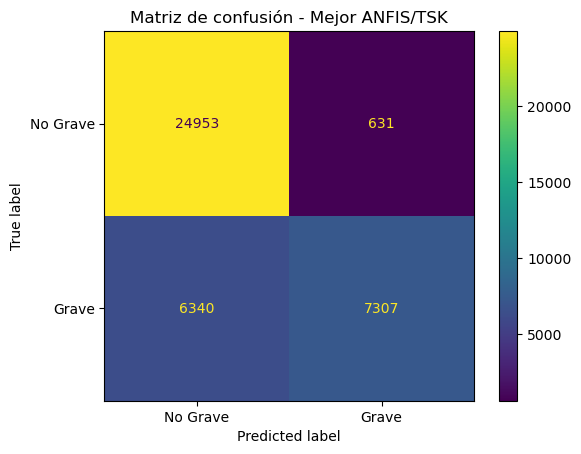

In [81]:
#Matriz de confusión del mejor modelo
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
threshold_base = 0.5
pred_test_final = (prob_test_final >= threshold_base).astype(int)

print("Métricas con threshold = 0.5")
print(classification_report(y_test_np, pred_test_final, target_names=['No Grave', 'Grave']))
cm = confusion_matrix(y_test_np, pred_test_final)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Grave', 'Grave']
)
disp.plot(values_format='d')
plt.title("Matriz de confusión - Mejor ANFIS/TSK")
plt.show()

La matriz de confusión del mejor ANFIS/TSK muestra que el modelo clasifica muy bien los casos No Graves: de 25.584 registros No Graves, identifica correctamente 24.953 y solo marca 631 como Graves. Sin embargo, en la clase Grave todavía deja pasar bastantes casos: de 13.647 registros Graves, identifica 7.307 y clasifica 6.340 como No Graves. Por eso la precisión de la clase Grave es alta, pero el recall queda moderado. Esto significa que el modelo es conservador: cuando predice Grave suele acertar, pero no detecta todos los casos graves.

**Ajuste del umbral de decisión**

In [82]:
# Evaluación de diferentes umbrales de decisión
umbrales = np.arange(0.20, 0.81, 0.05)
resultados_umbral = []

for th in umbrales:
    pred = (prob_test_final >= th).astype(int)
    resultados_umbral.append({
        'threshold': th,
        'accuracy': accuracy_score(y_test_np, pred),
        'precision_grave': precision_score(y_test_np, pred, zero_division=0),
        'recall_grave': recall_score(y_test_np, pred, zero_division=0),
        'f1_grave': f1_score(y_test_np, pred, zero_division=0),
        'auc_roc': roc_auc_score(y_test_np, prob_test_final)
    })
df_umbrales = pd.DataFrame(resultados_umbral)
df_umbrales.sort_values(by='f1_grave', ascending=False)

,threshold,accuracy,precision_grave,recall_grave,f1_grave,auc_roc
3,0.35,0.808774,0.787768,0.616326,0.691580,0.835471
4,0.40,0.818791,0.848433,0.583278,0.691302,0.835471
2,0.30,0.785731,0.700697,0.670404,0.685216,0.835471
5,0.45,0.822462,0.895104,0.554627,0.684884,0.835471
1,0.25,0.763096,0.641102,0.724628,0.680311,0.835471
6,0.50,0.822309,0.920509,0.535429,0.677044,0.835471
7,0.55,0.821391,0.937995,0.520994,0.669902,0.835471
8,0.60,0.821544,0.957840,0.509416,0.665104,0.835471
9,0.65,0.821264,0.964051,0.505019,0.662820,0.835471
10,0.70,0.820678,0.964848,0.502821,0.661111,0.835471


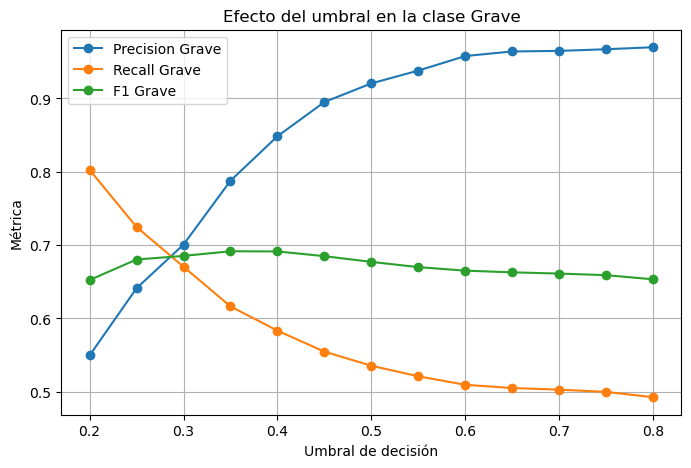

In [83]:
plt.figure(figsize=(8,5))
plt.plot(df_umbrales['threshold'], df_umbrales['precision_grave'], marker='o', label='Precision Grave')
plt.plot(df_umbrales['threshold'], df_umbrales['recall_grave'], marker='o', label='Recall Grave')
plt.plot(df_umbrales['threshold'], df_umbrales['f1_grave'], marker='o', label='F1 Grave')
plt.xlabel("Umbral de decisión")
plt.ylabel("Métrica")
plt.title("Efecto del umbral en la clase Grave")
plt.legend()
plt.grid(True)
plt.show()

Con umbral 0.5 se obtiene F1 de 0.677, precisión de 0.920 y recall de 0.535. Al bajar el umbral a 0.35, el F1 sube a 0.691, el recall mejora a 0.616 y la precisión sigue siendo aceptable, 0.787. Esto es importante porque un agente preventivo no debería priorizar únicamente la precisión, sino también detectar una mayor proporción de siniestros graves.

**Importancia de variables por permutación**

In [84]:
def evaluar_metricas_prob(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, pred),
        'precision_grave': precision_score(y_true, pred, zero_division=0),
        'recall_grave': recall_score(y_true, pred, zero_division=0),
        'f1_grave': f1_score(y_true, pred, zero_division=0),
        'auc_roc': roc_auc_score(y_true, prob)
    }
metricas_base = evaluar_metricas_prob(y_test_np, prob_test_final, threshold=0.5)
metricas_base

{'accuracy': 0.822308888379088,
 'precision_grave': 0.9205089443184681,
 'recall_grave': 0.5354290320216898,
 'f1_grave': 0.6770442436877461,
 'auc_roc': 0.8354707699997337}

In [85]:
def permutation_importance_anfis(
    model,
    X_test,
    y_test,
    variables,
    threshold=0.5,
    seed=42
):
    rng = np.random.default_rng(seed)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        prob_base = torch.sigmoid(model(X_test_tensor)).cpu().numpy()
    
    base_metrics = evaluar_metricas_prob(y_test, prob_base, threshold=threshold)
    importancias = []
    
    for j, var in enumerate(variables):
        X_perm = X_test.copy()
        X_perm[:, j] = rng.permutation(X_perm[:, j])
        X_perm_tensor = torch.tensor(X_perm, dtype=torch.float32)
        
        with torch.no_grad():
            prob_perm = torch.sigmoid(model(X_perm_tensor)).cpu().numpy()
        
        perm_metrics = evaluar_metricas_prob(y_test, prob_perm, threshold=threshold)
        importancias.append({
            'variable': var,
            'f1_base': base_metrics['f1_grave'],
            'f1_permutado': perm_metrics['f1_grave'],
            'caida_f1': base_metrics['f1_grave'] - perm_metrics['f1_grave'],
            'auc_base': base_metrics['auc_roc'],
            'auc_permutado': perm_metrics['auc_roc'],
            'caida_auc': base_metrics['auc_roc'] - perm_metrics['auc_roc']
        })
    return pd.DataFrame(importancias).sort_values(by='caida_f1', ascending=False)

df_importancia = permutation_importance_anfis(
    model=modelo_final,
    X_test=X_test_best,
    y_test=y_test_np,
    variables=variables_best,
    threshold=0.5,
    seed=42
)
df_importancia

,variable,f1_base,f1_permutado,caida_f1,auc_base,auc_permutado,caida_auc
7,riesgo_clase_siniestro,0.677044,0.472381,0.204663,0.835471,0.696098,0.139372
3,riesgo_tipo_vehiculo,0.677044,0.569373,0.107671,0.835471,0.764297,0.071174
6,riesgo_diseno_lugar,0.677044,0.669609,0.007435,0.835471,0.802660,0.032811
2,riesgo_localidad,0.677044,0.672738,0.004306,0.835471,0.816902,0.018569
0,HORA,0.677044,0.675385,0.001659,0.835471,0.833747,0.001724
4,precip_promedio_bogota,0.677044,0.676029,0.001015,0.835471,0.834904,0.000567
5,Festivo,0.677044,0.676950,0.000094,0.835471,0.835113,0.000357
1,num_vehiculos,0.677044,0.677258,-0.000214,0.835471,0.835514,-0.000043


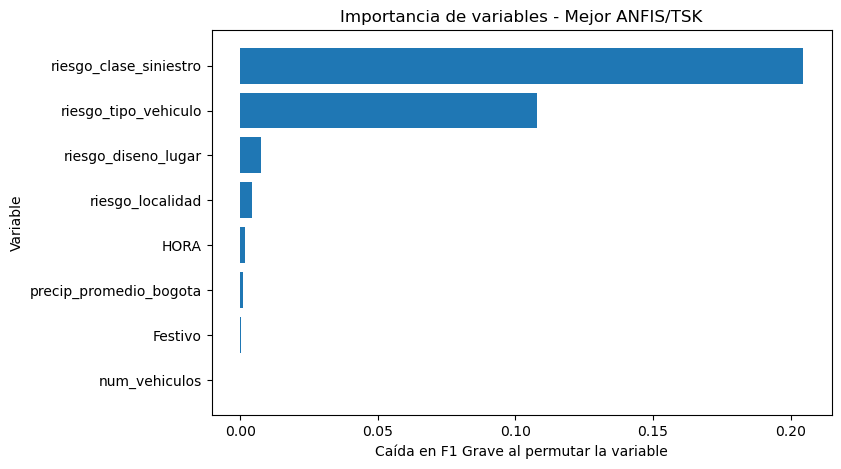

In [86]:
plt.figure(figsize=(8,5))
plt.barh(df_importancia['variable'], df_importancia['caida_f1'])
plt.xlabel("Caída en F1 Grave al permutar la variable")
plt.ylabel("Variable")
plt.title("Importancia de variables - Mejor ANFIS/TSK")
plt.gca().invert_yaxis()
plt.show()

La importancia por permutación muestra que riesgo_clase_siniestro es la variable más influyente: al permutarla, el F1 baja de 0.677 a 0.472. Después aparece riesgo_tipo_vehiculo, con una caída de F1 de 0.108. Las demás variables tienen un efecto menor en F1, aunque algunas como riesgo_diseno_lugar y riesgo_localidad sí afectan el AUC. Esto sugiere que el modelo aprendió principalmente a separar la gravedad a partir del tipo de siniestro y del tipo de vehículo, mientras que hora, precipitación, festivo y número de vehículos aportan menos en esta configuración.

In [87]:
# Diccionario de clases
dic_localidad = df_diccionario_maestro[
    (df_diccionario_maestro['CAMPO_MODELO'] == 'CLASE_SINIESTRO')
]
dic_localidad[['CODIGO', 'DESCRIPCION']].sort_values(by='CODIGO')

,CODIGO,DESCRIPCION
4,1,Choque
5,2,Atropello
7,3,Volcamiento
6,4,Caida de ocupante
9,5,Incendio
8,6,Otro
3,7,Autolesion


### Segunda fase experimental ANFIS/TSK

Después del primer diseño experimental, se realizó un análisis posterior del mejor modelo mediante matriz de confusión, ajuste del umbral e importancia por permutación. Este análisis mostró dos hallazgos principales. Primero, el umbral de decisión de 0.5 producía un modelo muy preciso, pero con recall moderado para la clase Grave; por esta razón, se evaluaron umbrales alternativos y se identificó que 0.35 ofrecía un mejor equilibrio entre precisión, recall y F1. Segundo, la variable riesgo_clase_siniestro resultó ser la más influyente en el desempeño del modelo, pero solo estaba presente en el conjunto de 8 variables. Por lo tanto, se decidió ejecutar una segunda fase experimental incorporando esta variable desde los conjuntos de menor dimensión, con el fin de evaluar si era posible mejorar el desempeño manteniendo un menor número de reglas.

In [60]:
# Incorporando riesgo_clase_siniestro desde el conjunto base y eliminando num_vehiculos que no tiene gran importancia.
vars_4 = [
    'riesgo_clase_siniestro',
    'riesgo_tipo_vehiculo',
    'riesgo_diseno_lugar',
    'riesgo_localidad'
]

vars_5 = vars_4 + [
    'HORA'
]

vars_7 = vars_5 + [
    'precip_promedio_bogota',
    'Festivo'
]

vars_8 = vars_7 + [
    'Hay_Evento'
]

conjuntos_variables = {
    '4_variables': vars_4,
    '5_variables': vars_5,
    '7_variables': vars_7,
    '8_variables': vars_8
}

for nombre, variables in conjuntos_variables.items():
    faltantes = [v for v in variables if v not in X_train_anfis_base.columns]
    print(nombre, "-> faltantes:", faltantes)

4_variables -> faltantes: []
5_variables -> faltantes: []
7_variables -> faltantes: []
8_variables -> faltantes: []


In [61]:
from sklearn.preprocessing import MinMaxScaler
datasets_anfis = {}
for nombre, variables in conjuntos_variables.items():
    variables_validas = [v for v in variables if v in X_train_anfis_base.columns]
    
    X_train_sel = X_train_anfis_base[variables_validas].copy()
    X_test_sel = X_test_anfis_base[variables_validas].copy()
    
    X_train_sel = X_train_sel.fillna(X_train_sel.median(numeric_only=True))
    X_test_sel = X_test_sel.fillna(X_train_sel.median(numeric_only=True))
    
    scaler = MinMaxScaler()
    
    X_train_scaled = scaler.fit_transform(X_train_sel)
    X_test_scaled = scaler.transform(X_test_sel)
    
    datasets_anfis[nombre] = {
        'variables': variables_validas,
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'scaler': scaler
    }
    print(f"\n{nombre}")
    print("Variables:", variables_validas)
    print("Shape train:", X_train_scaled.shape)
    print("Shape test:", X_test_scaled.shape)


4_variables
Variables: ['riesgo_clase_siniestro', 'riesgo_tipo_vehiculo', 'riesgo_diseno_lugar', 'riesgo_localidad']
Shape train: (156921, 4)
Shape test: (39231, 4)

5_variables
Variables: ['riesgo_clase_siniestro', 'riesgo_tipo_vehiculo', 'riesgo_diseno_lugar', 'riesgo_localidad', 'HORA']
Shape train: (156921, 5)
Shape test: (39231, 5)

7_variables
Variables: ['riesgo_clase_siniestro', 'riesgo_tipo_vehiculo', 'riesgo_diseno_lugar', 'riesgo_localidad', 'HORA', 'precip_promedio_bogota', 'Festivo']
Shape train: (156921, 7)
Shape test: (39231, 7)

8_variables
Variables: ['riesgo_clase_siniestro', 'riesgo_tipo_vehiculo', 'riesgo_diseno_lugar', 'riesgo_localidad', 'HORA', 'precip_promedio_bogota', 'Festivo', 'Hay_Evento']
Shape train: (156921, 8)
Shape test: (39231, 8)


El diseño experimental queda igual en estructura, pero con threshold=0.35:

In [62]:
# Diseño experimental ajustado - segunda fase
tipos_membresia = ['triangular', 'gaussiana', 'campana']
semillas = [42, 2026]

diseño_experimental = []

for nombre_vars, variables in conjuntos_variables.items():
    n_variables = len(variables)
    if n_variables <= 7:
        niveles_membresia = [2, 3]
    else:
        niveles_membresia = [2]
    
    for n_mf in niveles_membresia:
        for tipo_mf in tipos_membresia:
            for seed in semillas:
                diseño_experimental.append({
                    'conjunto_variables': nombre_vars,
                    'num_variables': n_variables,
                    'num_membresias': n_mf,
                    'tipo_membresia': tipo_mf,
                    'semilla': seed,
                    'num_reglas_teoricas': n_mf ** n_variables
                })
df_diseño = pd.DataFrame(diseño_experimental)
print("Total de ejecuciones:", df_diseño.shape[0])
display(df_diseño.head(15))

Total de ejecuciones: 42


,conjunto_variables,num_variables,num_membresias,tipo_membresia,semilla,num_reglas_teoricas
0,4_variables,4,2,triangular,42,16
1,4_variables,4,2,triangular,2026,16
2,4_variables,4,2,gaussiana,42,16
3,4_variables,4,2,gaussiana,2026,16
4,4_variables,4,2,campana,42,16
5,4_variables,4,2,campana,2026,16
6,4_variables,4,3,triangular,42,81
7,4_variables,4,3,triangular,2026,81
8,4_variables,4,3,gaussiana,42,81
9,4_variables,4,3,gaussiana,2026,81


### Ejecución segunda fase experimental ANFIS/TSK

In [66]:
# Ejecución segunda fase experimental ANFIS/TSK
resultados_anfis = []
for i, fila in df_diseño.iterrows():
    nombre_dataset = fila['conjunto_variables']
    n_mfs = int(fila['num_membresias'])
    mf_type = fila['tipo_membresia']
    seed = int(fila['semilla'])
    data = datasets_anfis[nombre_dataset]
    print(
        f"Ejecutando {i+1}/{len(df_diseño)} | "
        f"{nombre_dataset} | {n_mfs} membresías | {mf_type} | seed={seed}"
    )
    try:
        metricas = entrenar_evaluar_anfis(
            X_train=data['X_train'],
            y_train=y_train_np,
            X_test=data['X_test'],
            y_test=y_test_np,
            n_mfs=n_mfs,
            mf_type=mf_type,
            seed=seed,
            epochs=40,
            batch_size=512,
            lr=0.01,
            max_muestras_train=30000,
            threshold=0.35
        )
        
        resultado = fila.to_dict()
        resultado.update(metricas)
        resultado['variables_usadas'] = data['variables']
        resultado['estado'] = 'OK'
    
    except Exception as e:
        resultado = fila.to_dict()
        resultado['estado'] = 'ERROR'
        resultado['error'] = str(e)
    
    resultados_anfis.append(resultado)
df_resultados_anfis_2 = pd.DataFrame(resultados_anfis)
display(df_resultados_anfis_2.head())

Ejecutando 1/42 | 4_variables | 2 membresías | triangular | seed=42
Ejecutando 2/42 | 4_variables | 2 membresías | triangular | seed=2026
Ejecutando 3/42 | 4_variables | 2 membresías | gaussiana | seed=42
Ejecutando 4/42 | 4_variables | 2 membresías | gaussiana | seed=2026
Ejecutando 5/42 | 4_variables | 2 membresías | campana | seed=42
Ejecutando 6/42 | 4_variables | 2 membresías | campana | seed=2026
Ejecutando 7/42 | 4_variables | 3 membresías | triangular | seed=42
Ejecutando 8/42 | 4_variables | 3 membresías | triangular | seed=2026
Ejecutando 9/42 | 4_variables | 3 membresías | gaussiana | seed=42
Ejecutando 10/42 | 4_variables | 3 membresías | gaussiana | seed=2026
Ejecutando 11/42 | 4_variables | 3 membresías | campana | seed=42
Ejecutando 12/42 | 4_variables | 3 membresías | campana | seed=2026
Ejecutando 13/42 | 5_variables | 2 membresías | triangular | seed=42
Ejecutando 14/42 | 5_variables | 2 membresías | triangular | seed=2026
Ejecutando 15/42 | 5_variables | 2 membresías

,conjunto_variables,num_variables,num_membresias,tipo_membresia,semilla,num_reglas_teoricas,accuracy,precision_grave,recall_grave,f1_grave,auc_roc,tn,fp,fn,tp,tiempo_segundos,loss_final,num_reglas,variables_usadas,estado
0,4_variables,4,2,triangular,42,16,0.347863,0.347863,1.000000,0.516169,0.500000,0,25584,0,13647,23.191454,0.693147,16,"[riesgo_clase_siniestro, riesgo_tipo_vehiculo,...",OK
1,4_variables,4,2,triangular,2026,16,0.809283,0.791655,0.613102,0.691031,0.826283,23382,2202,5280,8367,21.644773,0.507131,16,"[riesgo_clase_siniestro, riesgo_tipo_vehiculo,...",OK
2,4_variables,4,2,gaussiana,42,16,0.814381,0.832376,0.584011,0.686418,0.833512,23979,1605,5677,7970,22.277646,0.422455,16,"[riesgo_clase_siniestro, riesgo_tipo_vehiculo,...",OK
3,4_variables,4,2,gaussiana,2026,16,0.811552,0.808748,0.600205,0.689043,0.834834,23647,1937,5456,8191,21.766298,0.416577,16,"[riesgo_clase_siniestro, riesgo_tipo_vehiculo,...",OK
4,4_variables,4,2,campana,42,16,0.816089,0.844842,0.577343,0.685936,0.834505,24137,1447,5768,7879,21.148496,0.418739,16,"[riesgo_clase_siniestro, riesgo_tipo_vehiculo,...",OK


In [67]:
df_resultados_ok_2 = df_resultados_anfis_2[df_resultados_anfis_2['estado'] == 'OK'].copy()
df_resultados_ok_2 = df_resultados_ok_2.sort_values(
    by=['f1_grave', 'recall_grave', 'auc_roc'],
    ascending=False
)
display(df_resultados_ok_2[
    [
        'conjunto_variables',
        'num_variables',
        'num_membresias',
        'tipo_membresia',
        'semilla',
        'num_reglas',
        'accuracy',
        'precision_grave',
        'recall_grave',
        'f1_grave',
        'auc_roc',
        'tiempo_segundos',
        'loss_final'
    ]
].head(10))

,conjunto_variables,num_variables,num_membresias,tipo_membresia,semilla,num_reglas,accuracy,precision_grave,recall_grave,f1_grave,auc_roc,tiempo_segundos,loss_final
33,7_variables,7,3,gaussiana,2026,2187,0.812725,0.803761,0.610757,0.694092,0.839524,384.707016,0.414821
35,7_variables,7,3,campana,2026,2187,0.804084,0.759693,0.638895,0.694077,0.839821,260.806033,0.409548
34,7_variables,7,3,campana,42,2187,0.810889,0.795726,0.613981,0.693138,0.839461,263.069383,0.411455
23,5_variables,5,3,campana,2026,243,0.806250,0.771901,0.628856,0.693075,0.840397,39.076844,0.410592
40,8_variables,8,2,campana,42,256,0.807958,0.782774,0.619990,0.691937,0.835885,51.796343,0.415955
32,7_variables,7,3,gaussiana,42,2187,0.819479,0.853375,0.580860,0.691228,0.834537,386.128103,0.419804
1,4_variables,4,2,triangular,2026,16,0.809283,0.791655,0.613102,0.691031,0.826283,21.644773,0.507131
5,4_variables,4,2,campana,2026,16,0.806123,0.775367,0.623214,0.691014,0.833132,21.291537,0.416790
29,7_variables,7,2,campana,2026,128,0.807882,0.784822,0.616839,0.690764,0.835579,36.119537,0.415497
21,5_variables,5,3,gaussiana,2026,243,0.803650,0.764037,0.630175,0.690680,0.835932,42.570030,0.414330


Resumen promedio

In [70]:
resumen_config_2 = (
    df_resultados_ok_2
    .groupby(['conjunto_variables', 'num_variables', 'num_membresias', 'tipo_membresia'])
    .agg(
        f1_grave_mean=('f1_grave', 'mean'),
        f1_grave_std=('f1_grave', 'std'),
        recall_grave_mean=('recall_grave', 'mean'),
        recall_grave_std=('recall_grave', 'std'),
        precision_grave_mean=('precision_grave', 'mean'),
        auc_roc_mean=('auc_roc', 'mean'),
        accuracy_mean=('accuracy', 'mean'),
        tiempo_mean=('tiempo_segundos', 'mean'),
        num_reglas=('num_reglas', 'first')
    )
    .reset_index()
    .sort_values(by=['f1_grave_mean', 'recall_grave_mean', 'auc_roc_mean'], ascending=False)
)
display(resumen_config_2.head(25))

,conjunto_variables,num_variables,num_membresias,tipo_membresia,f1_grave_mean,f1_grave_std,recall_grave_mean,recall_grave_std,precision_grave_mean,auc_roc_mean,accuracy_mean,tiempo_mean,num_reglas
15,7_variables,7,3,campana,0.693608,0.000664,0.626438,0.017617,0.777710,0.839641,0.807486,261.937708,2187
16,7_variables,7,3,gaussiana,0.692660,0.002025,0.595809,0.021140,0.828568,0.837031,0.816102,385.417560,2187
9,5_variables,5,3,campana,0.691137,0.002740,0.614384,0.020467,0.790807,0.839528,0.809016,39.643676,243
18,8_variables,8,2,campana,0.690312,0.002297,0.609438,0.014922,0.796472,0.835518,0.809806,49.647175,256
12,7_variables,7,2,campana,0.689950,0.001152,0.608449,0.011865,0.797046,0.835378,0.809781,36.674318,128
13,7_variables,7,2,gaussiana,0.689428,0.000844,0.614860,0.018239,0.785501,0.834069,0.807308,38.371728,128
4,4_variables,4,3,gaussiana,0.689392,0.000908,0.610647,0.015700,0.792153,0.835126,0.808595,25.460054,81
19,8_variables,8,2,gaussiana,0.689050,0.002210,0.598153,0.009845,0.812750,0.834769,0.812215,55.138865,256
10,5_variables,5,3,gaussiana,0.688837,0.002606,0.615557,0.020674,0.782928,0.835676,0.806582,42.971571,243
3,4_variables,4,3,campana,0.688707,0.002117,0.612003,0.028912,0.789665,0.834569,0.807588,26.341872,81


- Los modelos de 4 variables ya alcanzan resultados competitivos cuando incluyen las variables de riesgo histórico más relevantes: riesgo_clase_siniestro, riesgo_tipo_vehiculo, riesgo_diseno_lugar y riesgo_localidad. Esto confirma que la transformación de categóricas a riesgo histórico fue útil, porque resume información categórica importante sin generar dummies ni aumentar demasiado la dimensionalidad. En este grupo, las funciones campana y gaussiana tienen F1 cercano a 0.688–0.689, lo cual es muy similar a configuraciones más grandes.
- Con 5 variables, al agregar HORA, el desempeño mejora muy poco. La mejor configuración de este grupo fue 5 variables + 3 membresías + campana, con F1 promedio de 0.6911. Esto sugiere que la hora sí puede aportar algo, pero no tanto como las variables de riesgo histórico. Aun así, el modelo mantiene una complejidad razonable, con 243 reglas cuando usa 3 membresías.
- Con 7 variables, al agregar precip_promedio_bogota y Festivo, aparece la mejor configuración general: 7 variables + 3 membresías + campana. Este resultado sugiere que la información climática y de calendario sí agrega valor cuando el modelo ya cuenta con las variables estructurales más importantes. Además, con 3 membresías el modelo puede representar niveles bajo/medio/alto para cada entrada, lo que parece haber mejorado la separación de la clase Grave. Sin embargo, esta mejora tiene un costo computacional alto: 2187 reglas y un tiempo promedio de entrenamiento cercano a 262 segundos.
- Con 8 variables, al agregar Hay_Evento, el desempeño no mejora frente a 7 variables. De hecho, las mejores configuraciones de 8 variables con 2 membresías quedan alrededor de F1 0.690. Esto indica que Hay_Evento no aportó suficiente información adicional para compensar la complejidad del modelo. En este caso, más variables no necesariamente fue mejor; lo importante fue escoger variables informativas.

La función campana volvió a ser la más conveniente. Esto tiene sentido porque es una función de membresía suave y flexible, capaz de representar transiciones graduales entre niveles de riesgo. La gaussiana tuvo resultados muy cercanos, lo que confirma que las funciones suaves funcionaron mejor que la triangular. En cambio, la función triangular volvió a tener los peores resultados. Varias configuraciones triangulares obtuvieron recall cercano a 1.0, pero con precisión muy baja y accuracy cercana a la proporción de la clase Grave. Esto indica que el modelo tendió a clasificar casi todo como Grave, lo cual infla artificialmente el recall pero no representa una buena capacidad de discriminación.

**Mejor configuración**

In [69]:
mejor_config_2 = resumen_config_2.iloc[0]
print("Mejor configuración promedio - Segunda fase:")
print(mejor_config_2)

mejor_nombre_dataset_2 = mejor_config_2['conjunto_variables']

print("\nVariables usadas en la mejor configuración:")
print(datasets_anfis[mejor_nombre_dataset_2]['variables'])

Mejor configuración promedio - Segunda fase:
conjunto_variables      7_variables
num_variables                     7
num_membresias                    3
tipo_membresia              campana
f1_grave_mean              0.693608
f1_grave_std               0.000664
recall_grave_mean          0.626438
recall_grave_std           0.017617
precision_grave_mean        0.77771
auc_roc_mean               0.839641
accuracy_mean              0.807486
tiempo_mean              261.937708
num_reglas                     2187
Name: 15, dtype: object

Variables usadas en la mejor configuración:
['riesgo_clase_siniestro', 'riesgo_tipo_vehiculo', 'riesgo_diseno_lugar', 'riesgo_localidad', 'HORA', 'precip_promedio_bogota', 'Festivo']


En la segunda fase, la mejor configuración fue 7 variables + 3 membresías + campana, con F1 promedio de 0.6936, recall de 0.6264, precisión de 0.7777, AUC-ROC de 0.8396 y accuracy de 0.8075. Es decir, el recall aumentó de 0.53 a 0.63 y el F1 subió de 0.674 a 0.694. La precisión bajó porque el modelo ahora se atreve más a clasificar casos como graves, generando más falsos positivos, pero para un agente preventivo esto puede ser más conveniente que perder demasiados siniestros graves.

La mejora se explica principalmente por dos cambios:
- Primero, se incorporó `riesgo_clase_siniestro` desde los conjuntos pequeños de variables, después de observar que era la variable más importante en el análisis por permutación. En la primera fase, esa variable solo aparecía en el conjunto de 8 variables, lo que hacía que los conjuntos de 4, 5 y 7 variables estuvieran incompletos frente a la señal más fuerte del problema. 
- Segundo, se cambió el umbral de decisión de 0.5 a 0.35, porque el análisis de umbrales mostró que ese valor producía un mejor equilibrio entre precisión, recall y F1 para la clase Grave.


In [72]:
mejor_fila_individual_2 = df_resultados_ok_2.iloc[0]
mejor_dataset_2 = mejor_fila_individual_2['conjunto_variables']
mejor_n_mfs_2 = int(mejor_fila_individual_2['num_membresias'])
mejor_mf_type_2 = mejor_fila_individual_2['tipo_membresia']
mejor_seed_2 = int(mejor_fila_individual_2['semilla'])
print(mejor_fila_individual_2)

conjunto_variables                                           7_variables
num_variables                                                          7
num_membresias                                                         3
tipo_membresia                                                 gaussiana
semilla                                                             2026
num_reglas_teoricas                                                 2187
accuracy                                                        0.812725
precision_grave                                                 0.803761
recall_grave                                                    0.610757
f1_grave                                                        0.694092
auc_roc                                                         0.839524
tn                                                                 23549
fp                                                                  2035
fn                                                 

In [74]:
# Función para reentrenar ANFIS final
def entrenar_anfis_final(
    X_train,
    y_train,
    X_test,
    y_test,
    n_mfs=2,
    mf_type='campana',
    seed=2026,
    epochs=40,
    batch_size=512,
    lr=0.01,
    max_muestras_train=30000
):
    torch.manual_seed(seed)
    np.random.seed(seed)
    X_train_sub, y_train_sub = crear_submuestra_entrenamiento(
        X_train,
        y_train,
        max_muestras=max_muestras_train,
        seed=seed
    )
    X_train_tensor = torch.tensor(X_train_sub, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_sub, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    model = ANFIS_TSK(
        n_inputs=X_train.shape[1],
        n_mfs=n_mfs,
        mf_type=mf_type
    )
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )
    losses = []
    inicio = time.time()
    model.train()
    for epoch in range(epochs):
        epoch_losses = []
        
        for xb, yb in loader:
            optimizer.zero_grad()
            
            logits = model(xb)
            loss = criterion(logits, yb)
            
            loss.backward()
            optimizer.step()
            
            epoch_losses.append(loss.item())
        
        losses.append(np.mean(epoch_losses))
    tiempo = time.time() - inicio
    model.eval()
    with torch.no_grad():
        logits_test = model(X_test_tensor)
        prob_test = torch.sigmoid(logits_test).cpu().numpy()
    return model, prob_test, losses, tiempo

Variables del mejor modelo segunda fase:
['riesgo_clase_siniestro', 'riesgo_tipo_vehiculo', 'riesgo_diseno_lugar', 'riesgo_localidad', 'HORA', 'precip_promedio_bogota', 'Festivo']
Tiempo entrenamiento final: 252.20241403579712
Loss final: 0.4095478456909374

Reporte de clasificación - Mejor ANFIS/TSK segunda fase
              precision    recall  f1-score   support

    No Grave       0.82      0.89      0.86     25584
       Grave       0.76      0.64      0.69     13647

    accuracy                           0.80     39231
   macro avg       0.79      0.77      0.77     39231
weighted avg       0.80      0.80      0.80     39231



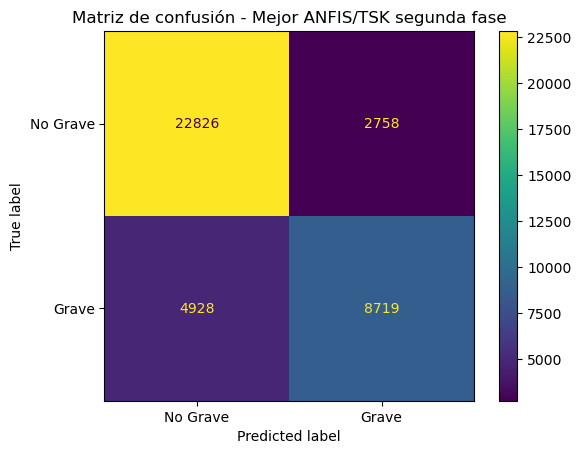

In [76]:
# Matriz de confusión - Mejor configuración segunda fase
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Mejor configuración segunda fase
mejor_dataset_2 = '7_variables'
mejor_n_mfs_2 = 3
mejor_mf_type_2 = 'campana'
mejor_seed_2 = 2026   # puedes cambiar a 42 si esa fue la mejor ejecución individual
mejor_threshold_2 = 0.35

data_best_2 = datasets_anfis[mejor_dataset_2]

X_train_best_2 = data_best_2['X_train']
X_test_best_2 = data_best_2['X_test']
variables_best_2 = data_best_2['variables']

print("Variables del mejor modelo segunda fase:")
print(variables_best_2)

modelo_final_2, prob_test_final_2, losses_final_2, tiempo_final_2 = entrenar_anfis_final(
    X_train=X_train_best_2,
    y_train=y_train_np,
    X_test=X_test_best_2,
    y_test=y_test_np,
    n_mfs=mejor_n_mfs_2,
    mf_type=mejor_mf_type_2,
    seed=mejor_seed_2,
    epochs=40,
    batch_size=512,
    lr=0.01,
    max_muestras_train=30000
)
pred_test_final_2 = (prob_test_final_2 >= mejor_threshold_2).astype(int)

print("Tiempo entrenamiento final:", tiempo_final_2)
print("Loss final:", losses_final_2[-1])

print("\nReporte de clasificación - Mejor ANFIS/TSK segunda fase")
print(classification_report(
    y_test_np,
    pred_test_final_2,
    target_names=['No Grave', 'Grave']
))

cm_2 = confusion_matrix(y_test_np, pred_test_final_2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_2,
    display_labels=['No Grave', 'Grave']
)
disp.plot(values_format='d')
plt.title("Matriz de confusión - Mejor ANFIS/TSK segunda fase")
plt.show()

La matriz de confusión de la mejor configuración de la segunda fase muestra una mejora clara frente al primer mejor ANFIS/TSK. El modelo clasificó correctamente 22.826 siniestros No Graves y 8.719 siniestros Graves. También produjo 2.758 falsos positivos, es decir, casos No Graves clasificados como Graves, y 4.928 falsos negativos, que son los casos Graves que todavía no logra detectar.

Comparado con la primera fase, el modelo ahora detecta más siniestros graves: antes identificaba 7.307 casos graves y ahora identifica 8.719. Esto confirma que incorporar riesgo_clase_siniestro desde el inicio y usar un umbral de 0.35 ayudó a mejorar el recall. La desventaja es que aumentaron los falsos positivos, porque el modelo se volvió menos conservador. Este cambio es razonable, ya que en un sistema preventivo puede ser más grave dejar pasar un siniestro potencialmente grave que generar algunas alertas adicionales.

### Grados de pertenencia

In [77]:
# Grados de pertenencia para un caso específico
idx = 0  # cambia este índice para analizar otro siniestro
x_caso = torch.tensor(
    X_test_best_2[idx:idx+1],
    dtype=torch.float32
)
modelo_final_2.eval()
with torch.no_grad():
    mu = modelo_final_2.membership(x_caso).cpu().numpy()[0]
    logit = modelo_final_2(x_caso).item()
    prob_grave = 1 / (1 + np.exp(-logit))
print("Probabilidad estimada de Grave:", prob_grave)
print("Etiqueta real:", y_test_np[idx])
for i, var in enumerate(variables_best_2):
    print(f"\nVariable: {var}")
    for j in range(modelo_final_2.n_mfs):
        print(f"  Membresía {j+1}: {mu[i, j]:.4f}")

Probabilidad estimada de Grave: 0.2959436513772685
Etiqueta real: 0.0

Variable: riesgo_clase_siniestro
  Membresía 1: 0.5917
  Membresía 2: 0.0000
  Membresía 3: 0.0001

Variable: riesgo_tipo_vehiculo
  Membresía 1: 0.9954
  Membresía 2: 0.0000
  Membresía 3: 0.0015

Variable: riesgo_diseno_lugar
  Membresía 1: 0.0000
  Membresía 2: 0.9985
  Membresía 3: 0.9920

Variable: riesgo_localidad
  Membresía 1: 0.0000
  Membresía 2: 0.4788
  Membresía 3: 0.9988

Variable: HORA
  Membresía 1: 0.0000
  Membresía 2: 0.0124
  Membresía 3: 0.9997

Variable: precip_promedio_bogota
  Membresía 1: 0.9770
  Membresía 2: 0.0003
  Membresía 3: 0.0000

Variable: Festivo
  Membresía 1: 0.9508
  Membresía 2: 0.0000
  Membresía 3: 0.0000


In [78]:
# Interpretación lingüística de membresías
etiquetas_mf = {
    2: ['Bajo', 'Alto'],
    3: ['Bajo', 'Medio', 'Alto']
}
labels = etiquetas_mf[modelo_final_2.n_mfs]
idx = 0
x_caso = torch.tensor(
    X_test_best_2[idx:idx+1],
    dtype=torch.float32
)
with torch.no_grad():
    mu = modelo_final_2.membership(x_caso).cpu().numpy()[0]
    prob = torch.sigmoid(modelo_final_2(x_caso)).item()
print(f"Probabilidad de Grave: {prob:.4f}")
print(f"Clase real: {int(y_test_np[idx])}")
for i, var in enumerate(variables_best_2):
    grados = mu[i]
    etiqueta_dominante = labels[np.argmax(grados)]
    print(f"\n{var}: pertenencia dominante = {etiqueta_dominante}")
    for label, valor in zip(labels, grados):
        print(f"  {label}: {valor:.4f}")

Probabilidad de Grave: 0.2959
Clase real: 0

riesgo_clase_siniestro: pertenencia dominante = Bajo
  Bajo: 0.5917
  Medio: 0.0000
  Alto: 0.0001

riesgo_tipo_vehiculo: pertenencia dominante = Bajo
  Bajo: 0.9954
  Medio: 0.0000
  Alto: 0.0015

riesgo_diseno_lugar: pertenencia dominante = Medio
  Bajo: 0.0000
  Medio: 0.9985
  Alto: 0.9920

riesgo_localidad: pertenencia dominante = Alto
  Bajo: 0.0000
  Medio: 0.4788
  Alto: 0.9988

HORA: pertenencia dominante = Alto
  Bajo: 0.0000
  Medio: 0.0124
  Alto: 0.9997

precip_promedio_bogota: pertenencia dominante = Bajo
  Bajo: 0.9770
  Medio: 0.0003
  Alto: 0.0000

Festivo: pertenencia dominante = Bajo
  Bajo: 0.9508
  Medio: 0.0000
  Alto: 0.0000


In [83]:
# Ver registro original del caso analizado
idx = 0
print("Clase real:", y_test.iloc[idx])
cols_interes = [
    'CLASE_SINIESTRO',
    'CLASE_VEHICULO_PRINCIPAL',
    'DISENO_LUGAR',
    'CODIGO_LOCALIDAD',
    'HORA',
    'precip_promedio_bogota',
    'Festivo'
]
display(X_test_raw.iloc[[idx]][cols_interes])

Clase real: 0


,CLASE_SINIESTRO,CLASE_VEHICULO_PRINCIPAL,DISENO_LUGAR,CODIGO_LOCALIDAD,HORA,precip_promedio_bogota,Festivo
136554,1,1.0,2,3,11,1.6,0


Choque, Automovil, Intersección, Santa Fe, 11:00 am, 1.6, No era festivo.

In [85]:
print("Clase siniestro original:")
print(X_test_raw.iloc[idx]['CLASE_SINIESTRO'])
print("\nRiesgo histórico asociado:")
print(X_test_anfis_base.iloc[idx]['riesgo_clase_siniestro'])

Clase siniestro original:
1

Riesgo histórico asociado:
0.24189772588232722


Si para ese registro la pertenencia dominante fue Bajo, quiere decir que la clase del siniestro de ese caso pertenece más al grupo de bajo riesgo histórico de gravedad.

En este caso, el modelo vio señales mixtas. Por un lado, riesgo_clase_siniestro, riesgo_tipo_vehiculo, precip_promedio_bogota y Festivo tienen pertenencia dominante Bajo, lo que empuja la predicción hacia No Grave. Por otro lado, riesgo_localidad y HORA aparecen como Alto, y riesgo_diseno_lugar aparece entre Medio/Alto, lo que sí puede aumentar el riesgo. Aun así, las variables más importantes en el modelo eran riesgo_clase_siniestro y riesgo_tipo_vehiculo; como ambas salieron en Bajo, la probabilidad final de Grave quedó baja.

In [79]:
# Reglas difusas más activadas para un caso
def reglas_mas_activadas(model, x_caso, variables, top_n=5):
    model.eval()
    with torch.no_grad():
        mu = model.membership(x_caso)
        firing_strengths = []
        for j in range(model.n_inputs):
            firing_strengths.append(mu[:, j, model.rules[:, j]])
        
        w = torch.stack(firing_strengths, dim=2).prod(dim=2)
        w_norm = w / (w.sum(dim=1, keepdim=True) + 1e-8)
        
        w_np = w_norm.cpu().numpy()[0]
    
    labels = etiquetas_mf[model.n_mfs]
    top_idx = np.argsort(w_np)[::-1][:top_n]
    reglas = []
    for r in top_idx:
        condiciones = []
        
        for j, var in enumerate(variables):
            mf_idx = int(model.rules[r, j].item())
            condiciones.append(f"{var} es {labels[mf_idx]}")
        
        reglas.append({
            'regla': r,
            'activacion': w_np[r],
            'descripcion': "SI " + " Y ".join(condiciones) + " ENTONCES riesgo de gravedad"
        })
    return pd.DataFrame(reglas)
idx = 0
x_caso = torch.tensor(
    X_test_best_2[idx:idx+1],
    dtype=torch.float32
)
df_reglas_caso = reglas_mas_activadas(
    modelo_final_2,
    x_caso,
    variables_best_2,
    top_n=10
)
display(df_reglas_caso)

,regla,activacion,descripcion
0,153,0.334300,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
1,234,0.332112,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
2,126,0.160252,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
3,207,0.159203,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
4,144,0.004135,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
5,225,0.004108,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
6,117,0.001982,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
7,198,0.001969,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
8,639,0.000499,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...
9,720,0.000495,SI riesgo_clase_siniestro es Bajo Y riesgo_tip...


In [80]:
pd.set_option('display.max_colwidth', None)
display(df_reglas_caso)

,regla,activacion,descripcion
0,153,0.334300,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Bajo Y riesgo_diseno_lugar es Medio Y riesgo_localidad es Alto Y HORA es Alto Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
1,234,0.332112,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Bajo Y riesgo_diseno_lugar es Alto Y riesgo_localidad es Alto Y HORA es Alto Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
2,126,0.160252,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Bajo Y riesgo_diseno_lugar es Medio Y riesgo_localidad es Medio Y HORA es Alto Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
3,207,0.159203,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Bajo Y riesgo_diseno_lugar es Alto Y riesgo_localidad es Medio Y HORA es Alto Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
4,144,0.004135,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Bajo Y riesgo_diseno_lugar es Medio Y riesgo_localidad es Alto Y HORA es Medio Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
5,225,0.004108,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Bajo Y riesgo_diseno_lugar es Alto Y riesgo_localidad es Alto Y HORA es Medio Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
6,117,0.001982,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Bajo Y riesgo_diseno_lugar es Medio Y riesgo_localidad es Medio Y HORA es Medio Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
7,198,0.001969,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Bajo Y riesgo_diseno_lugar es Alto Y riesgo_localidad es Medio Y HORA es Medio Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
8,639,0.000499,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Alto Y riesgo_diseno_lugar es Medio Y riesgo_localidad es Alto Y HORA es Alto Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad
9,720,0.000495,SI riesgo_clase_siniestro es Bajo Y riesgo_tipo_vehiculo es Alto Y riesgo_diseno_lugar es Alto Y riesgo_localidad es Alto Y HORA es Alto Y precip_promedio_bogota es Bajo Y Festivo es Bajo ENTONCES riesgo de gravedad


Estas reglas muestran qué combinaciones difusas se activaron más para ese caso específico. La activación indica el peso relativo de cada regla en la predicción final. Por ejemplo, la regla 153 tuvo activación 0.3343, lo que significa que fue la regla que más contribuyó a la salida del modelo para ese registro.

Las reglas más activadas tienen un patrón muy parecido: riesgo_clase_siniestro Bajo, riesgo_tipo_vehiculo Bajo, precip_promedio_bogota Bajo y Festivo Bajo.

### Conclusiones

**El número de reglas por sí solo no explica el desempeño**. La mejor configuración tiene 2187 reglas, mientras que en la primera fase ganó una configuración con 256 reglas. Sin embargo, no se puede concluir que “más reglas siempre es mejor”, porque otras configuraciones con 2187 reglas y función triangular fueron muy malas. Lo que parece importar más es la combinación entre variables informativas, tipo de membresía y granularidad adecuada. En este caso, 3 membresías ayudaron porque las variables elegidas eran más relevantes y la función campana permitió modelar mejor las transiciones difusas.

La primera fase produjo un modelo más rápido, más preciso y con mayor accuracy, pero menos sensible a la clase Grave. La segunda fase produjo un modelo más equilibrado para prevención, con mejor F1 y mayor recall, aunque con menor precisión, menor accuracy y mayor tiempo de entrenamiento. Para SiniBogotá, la segunda configuración es más defendible si el objetivo es apoyar alertas preventivas, porque detecta más casos graves sin caer en el extremo de clasificar todo como Grave.

El análisis lingüístico del mejor ANFIS/TSK permitió observar que la predicción no se produce únicamente como una etiqueta binaria, sino como una combinación de reglas difusas activadas parcialmente. En el caso analizado, aunque algunas condiciones como la hora y la localidad presentaban pertenencia alta a zonas de riesgo, las variables más determinantes, especialmente el riesgo histórico de la clase de siniestro y del tipo de vehículo, tuvieron pertenencia dominante baja. Esto llevó a una probabilidad estimada de gravedad inferior al umbral de decisión y a una clasificación correcta como No Grave. Este resultado evidencia el aporte principal de ANFIS/TSK frente a modelos como MLP: no necesariamente mejora el desempeño predictivo, pero permite explicar la decisión mediante grados de pertenencia, reglas activadas y razonamiento gradual sobre los factores de riesgo.

Al comparar ANFIS/TSK con la MLP optimizada mediante algoritmo genético, la MLP+AG obtiene un desempeño claramente superior: accuracy de 0.9142, precision Grave de 0.9252, recall Grave de 0.8197, F1 Grave de 0.8693 y ROC-AUC de 0.9560. Esto se explica porque la MLP puede trabajar con muchas más variables, incluyendo dummies, y aprender interacciones complejas sin construir reglas explícitas. ANFIS/TSK, en cambio, debe limitar el número de entradas para evitar una explosión en el número de reglas. Por eso, la MLP+AG es más adecuada como modelo predictivo final de la aplicación, mientras que ANFIS/TSK aporta valor como modelo interpretable de razonamiento con incertidumbre, útil para explicar el riesgo de forma gradual mediante membresías y reglas.